# HRN Output Analysis

This notebook analyzes seeded training/test artifacts in `/scratch/g.saggini1/outputs/`. Each experiment is a parent directory containing `seed_<seed>` runs; curves and final metrics report the mean and sample standard deviation across those seeds.

It compares:

- HRN baselines: `hrn_<dataset>`
- coarse-first lexicographic runs: `hrn_<dataset>_level_marginal_lex_coarse_first`
- the HCC arm: `hrn_<dataset>_level_marginal_hcc` (HCC is a binary on/off switch, active for the whole run)

It uses the same analysis utilities and plotting layout as `hcast_analysis.ipynb`, with run names changed to HRN.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'configs').is_dir()), cwd)
notebook_utils_dir = repo_root / 'notebooks' / 'utils'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import (
    HCastAnalysis as HRNAnalysis,
    HCastAnalysisConfig as HRNAnalysisConfig,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [2]:
INCLUDE_BASELINES = True
INCLUDE_TOPDOWN_METRICS = True
BASELINE_COLOR = '#243ab4'

DATASET_SLUGS = {
    'cifar-100': 'cifar100',
    'cub-200-2011': 'cub200',
    'fgvc-aircraft': 'aircraft',
}
HRN_DATASETS = tuple(DATASET_SLUGS.values())

BASELINE_BY_DATASET = {
    dataset_key: {'run_dir': f'hrn_{dataset}', 'label': 'HRN baseline'}
    for dataset_key, dataset in DATASET_SLUGS.items()
}

MANUAL_RUNS = [
    *[
        {'run_dir': f'hrn_{dataset}_level_marginal_lex_coarse_first',
            'label': f'HRN level_marginal lex coarse_first'}
        for dataset in HRN_DATASETS
    ],
    # HCC arm: a binary on/off switch, active for the whole run. HRN needs
    # model.loss=level_marginal so the objective decomposes into the three
    # per-level terms HCC is defined on; see scripts/hrn/run_hrn_hcc.sh.
    *[
        {'run_dir': f'hrn_{dataset}_level_marginal_hcc',
            'label': f'HRN level_marginal HCC'}
        for dataset in HRN_DATASETS
    ],
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]

In [3]:
config = HRNAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    include_topdown_metrics=INCLUDE_TOPDOWN_METRICS,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HRNAnalysis.from_config(config)
analysis.print_run_summary()

Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hrn_cifar100_level_marginal_hcc
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hrn_cub200_level_marginal_hcc
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hrn_aircraft_level_marginal_hcc
[cifar-100] HRN baseline: epochs=200, best_td_epoch=191.66666666666666, best_ind_epoch=188.0, baseline, seeds=[0, 1, 2]
[cifar-100] HRN level_marginal lex coarse_first: epochs=200, best_td_epoch=126.66666666666667, best_ind_epoch=129.33333333333334, seeds=[0, 1, 2]
[cub-200-2011] HRN baseline: epochs=200, best_td_epoch=130.33333333333334, best_ind_epoch=168.0, baseline, seeds=[0, 1, 2]
[cub-200-2011] HRN level_marginal lex coarse_first: epochs=200, best_td_epoch=143.66666666666666, best_ind_epoch=138.33333333333334, seeds=[0, 1, 2]
[fgvc-aircraft] HRN baseline: epochs=200, best_td_epoch=172.0, best_ind_epoch=190.33333333333334, baseline, seeds=[0, 1, 2]
[fgvc-aircraft] HRN level_marginal lex coarse_fir

## HRN Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- solid line = top-down decoding
- dashed line = independent decoding
- color = run

This makes decoder dependence visible when comparing HRN runs.

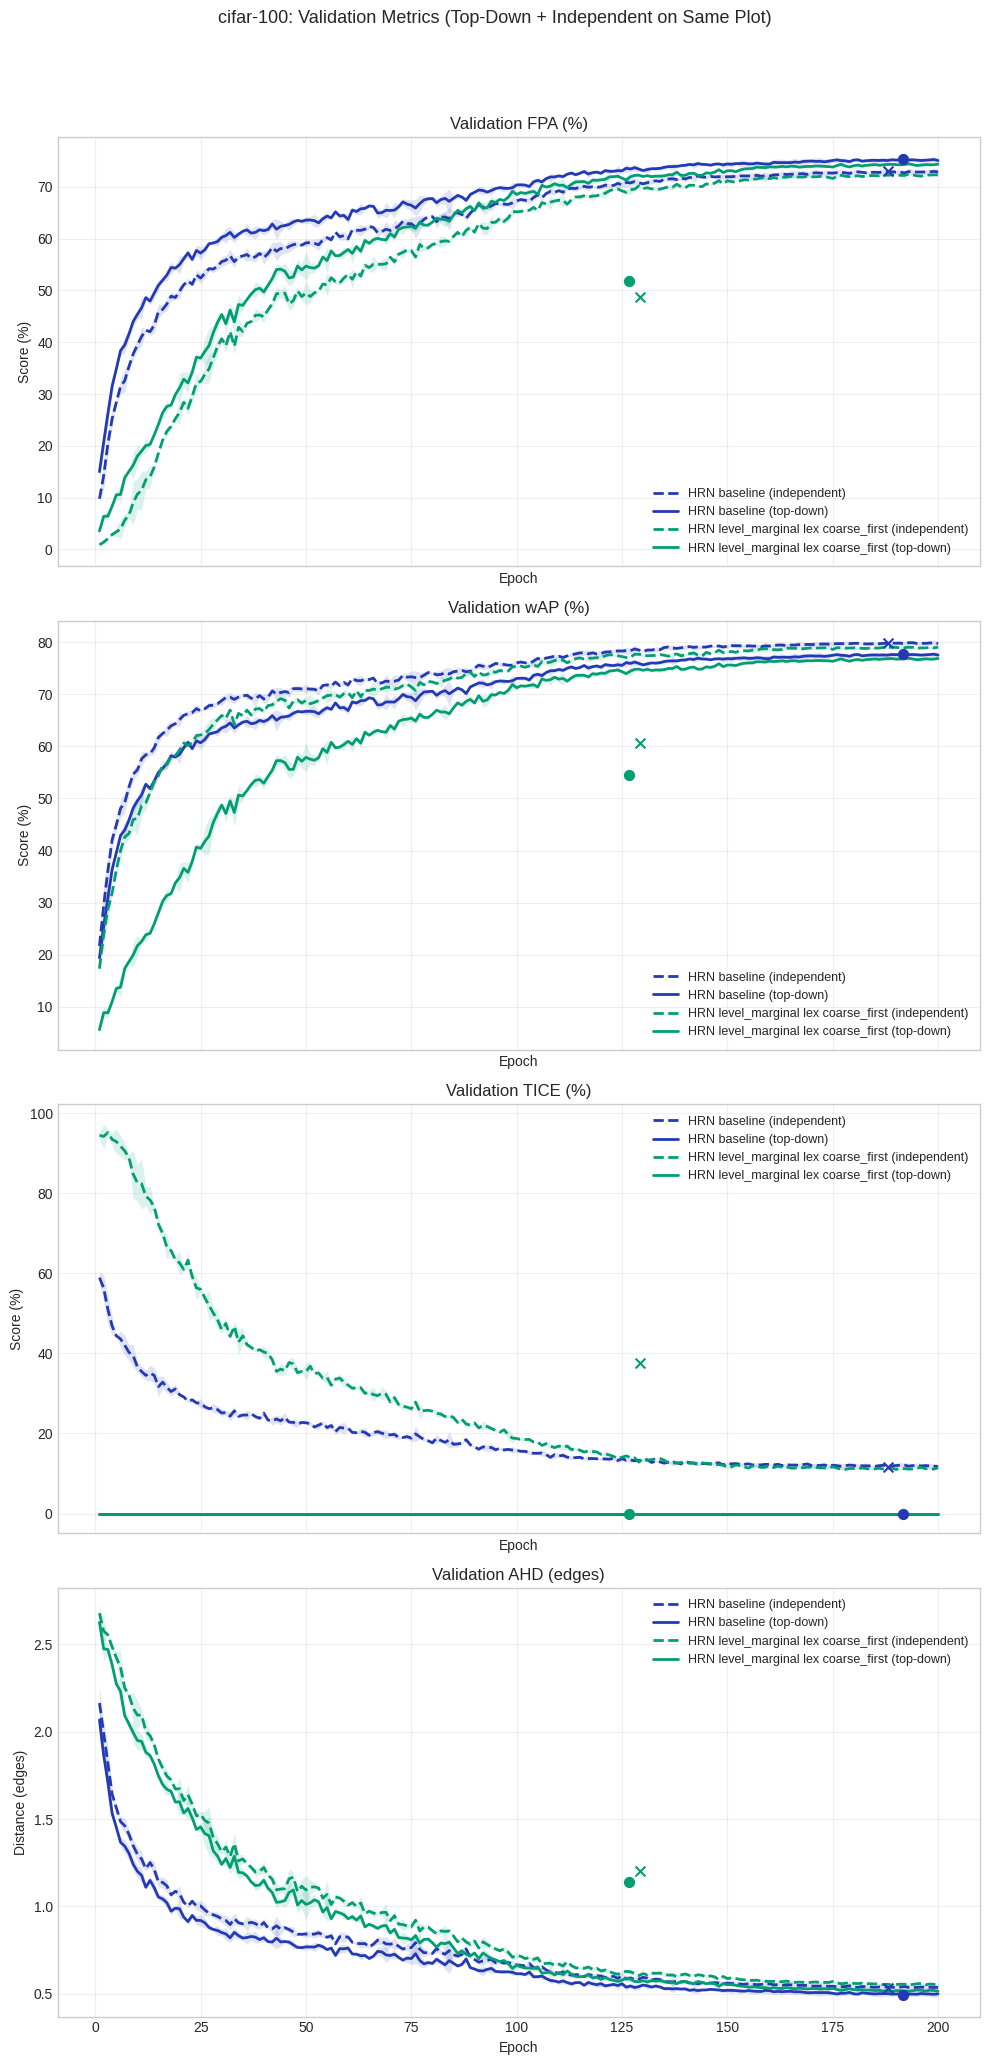

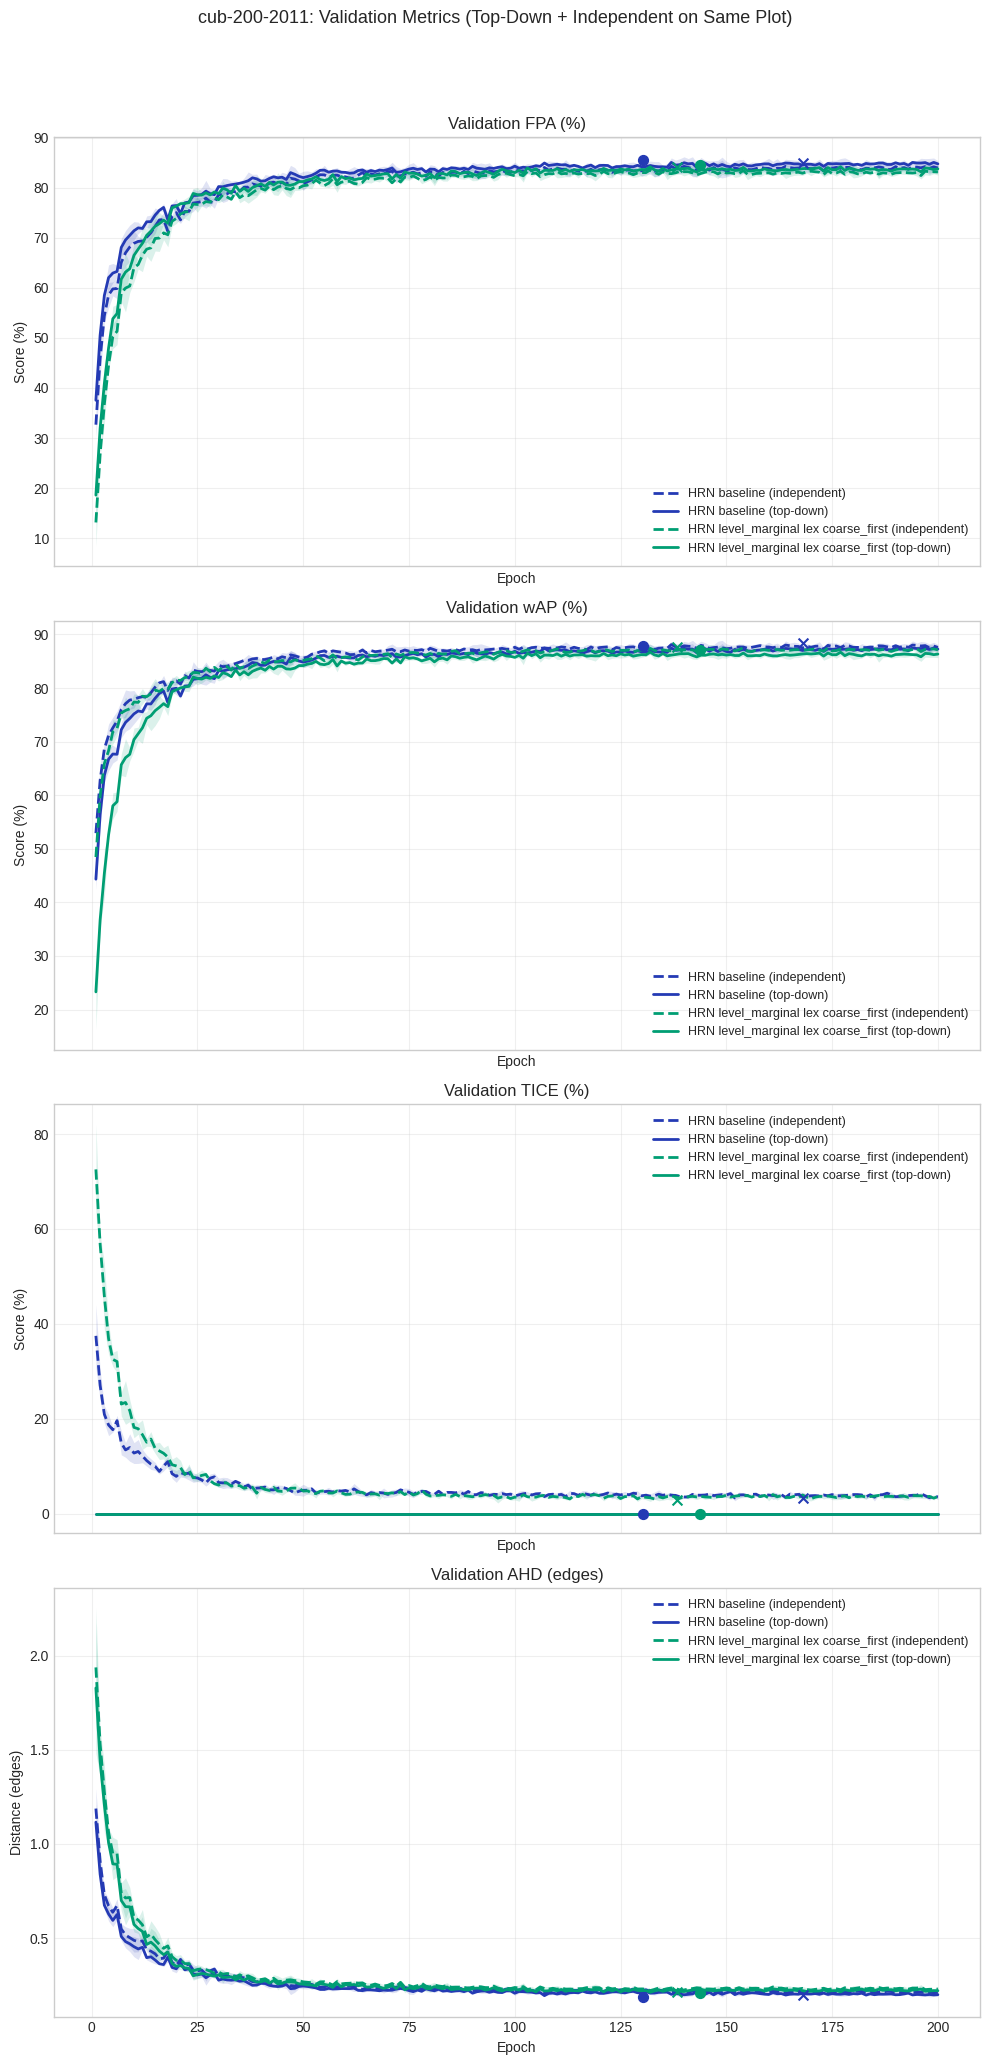

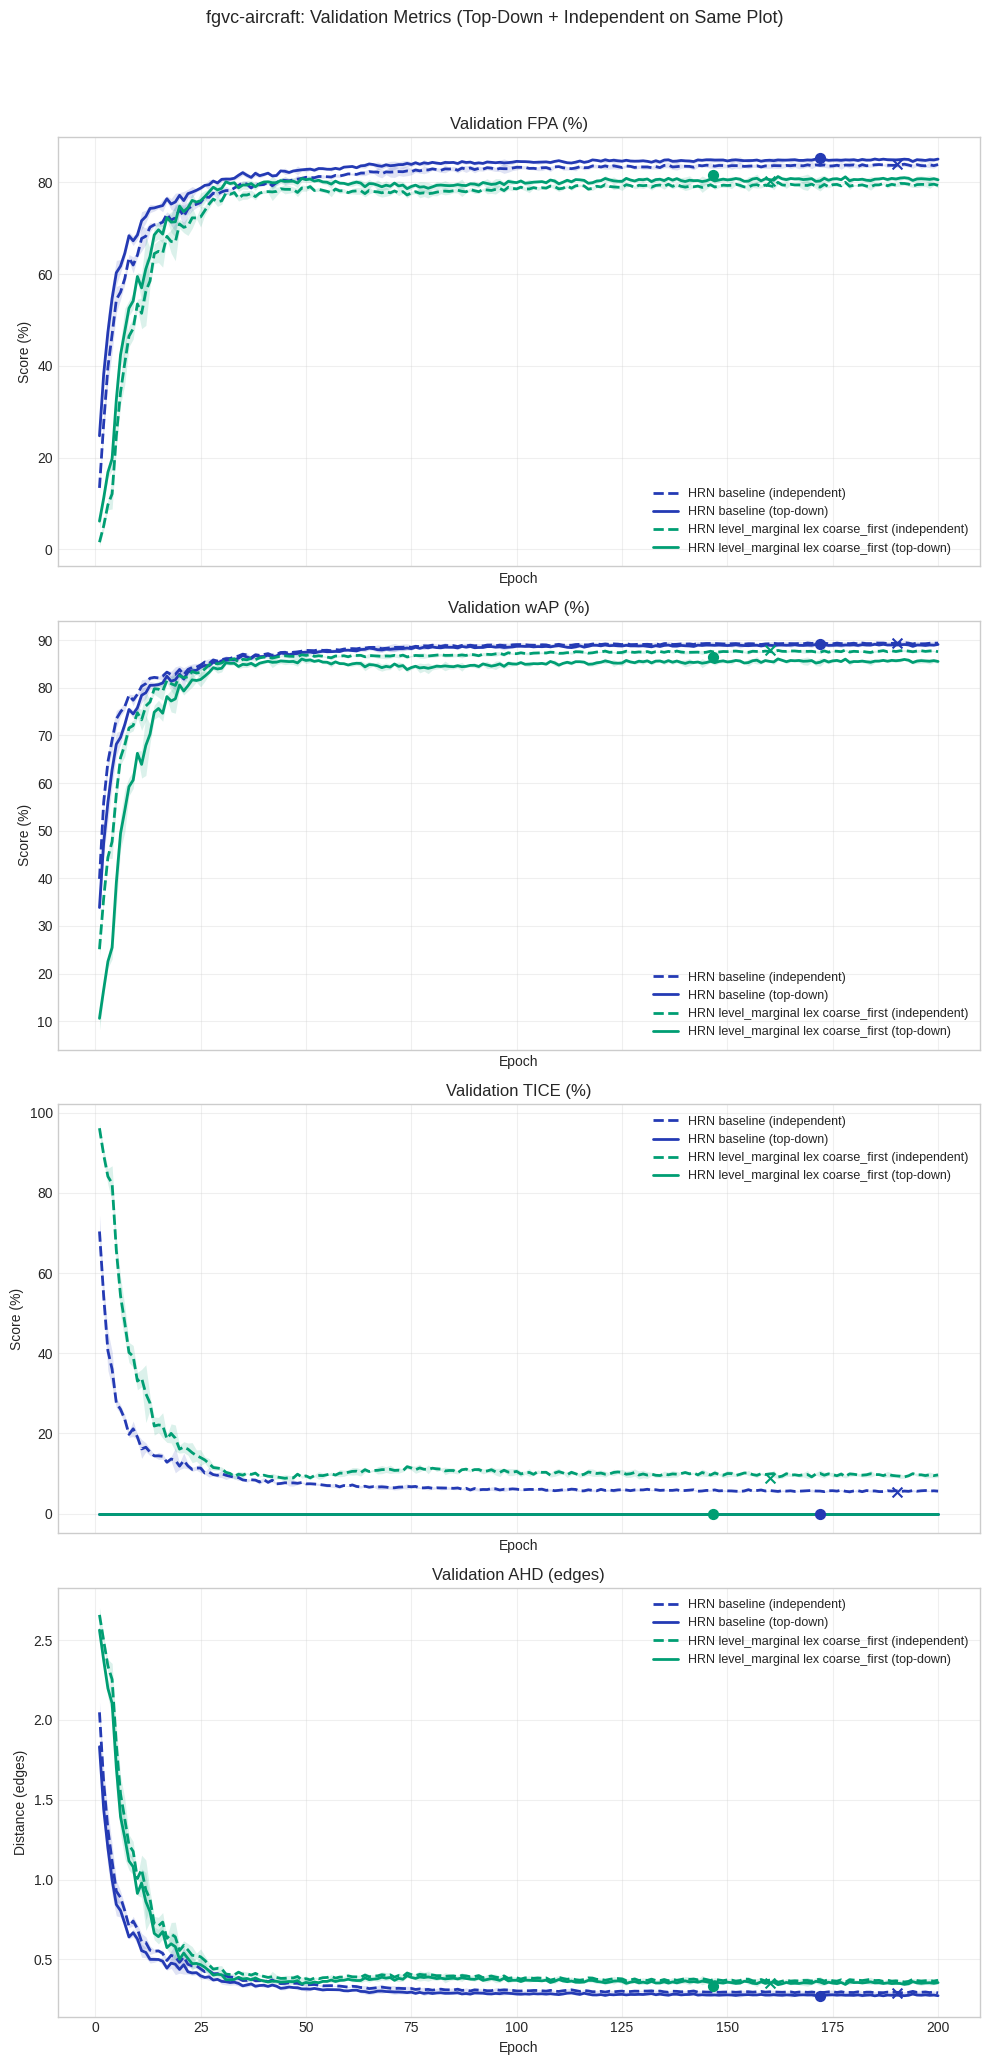

In [4]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate the effect of top-down decoding.
- Compare colors within a dataset to isolate the effect of each HRN training variant.

## HRN Consistency Diagnostics

This section uses HRN's logged level-2 projection/parent-consistency diagnostics when present:

- projection flip rate
- projection L1 delta
- ground-truth parent mass before and after projection

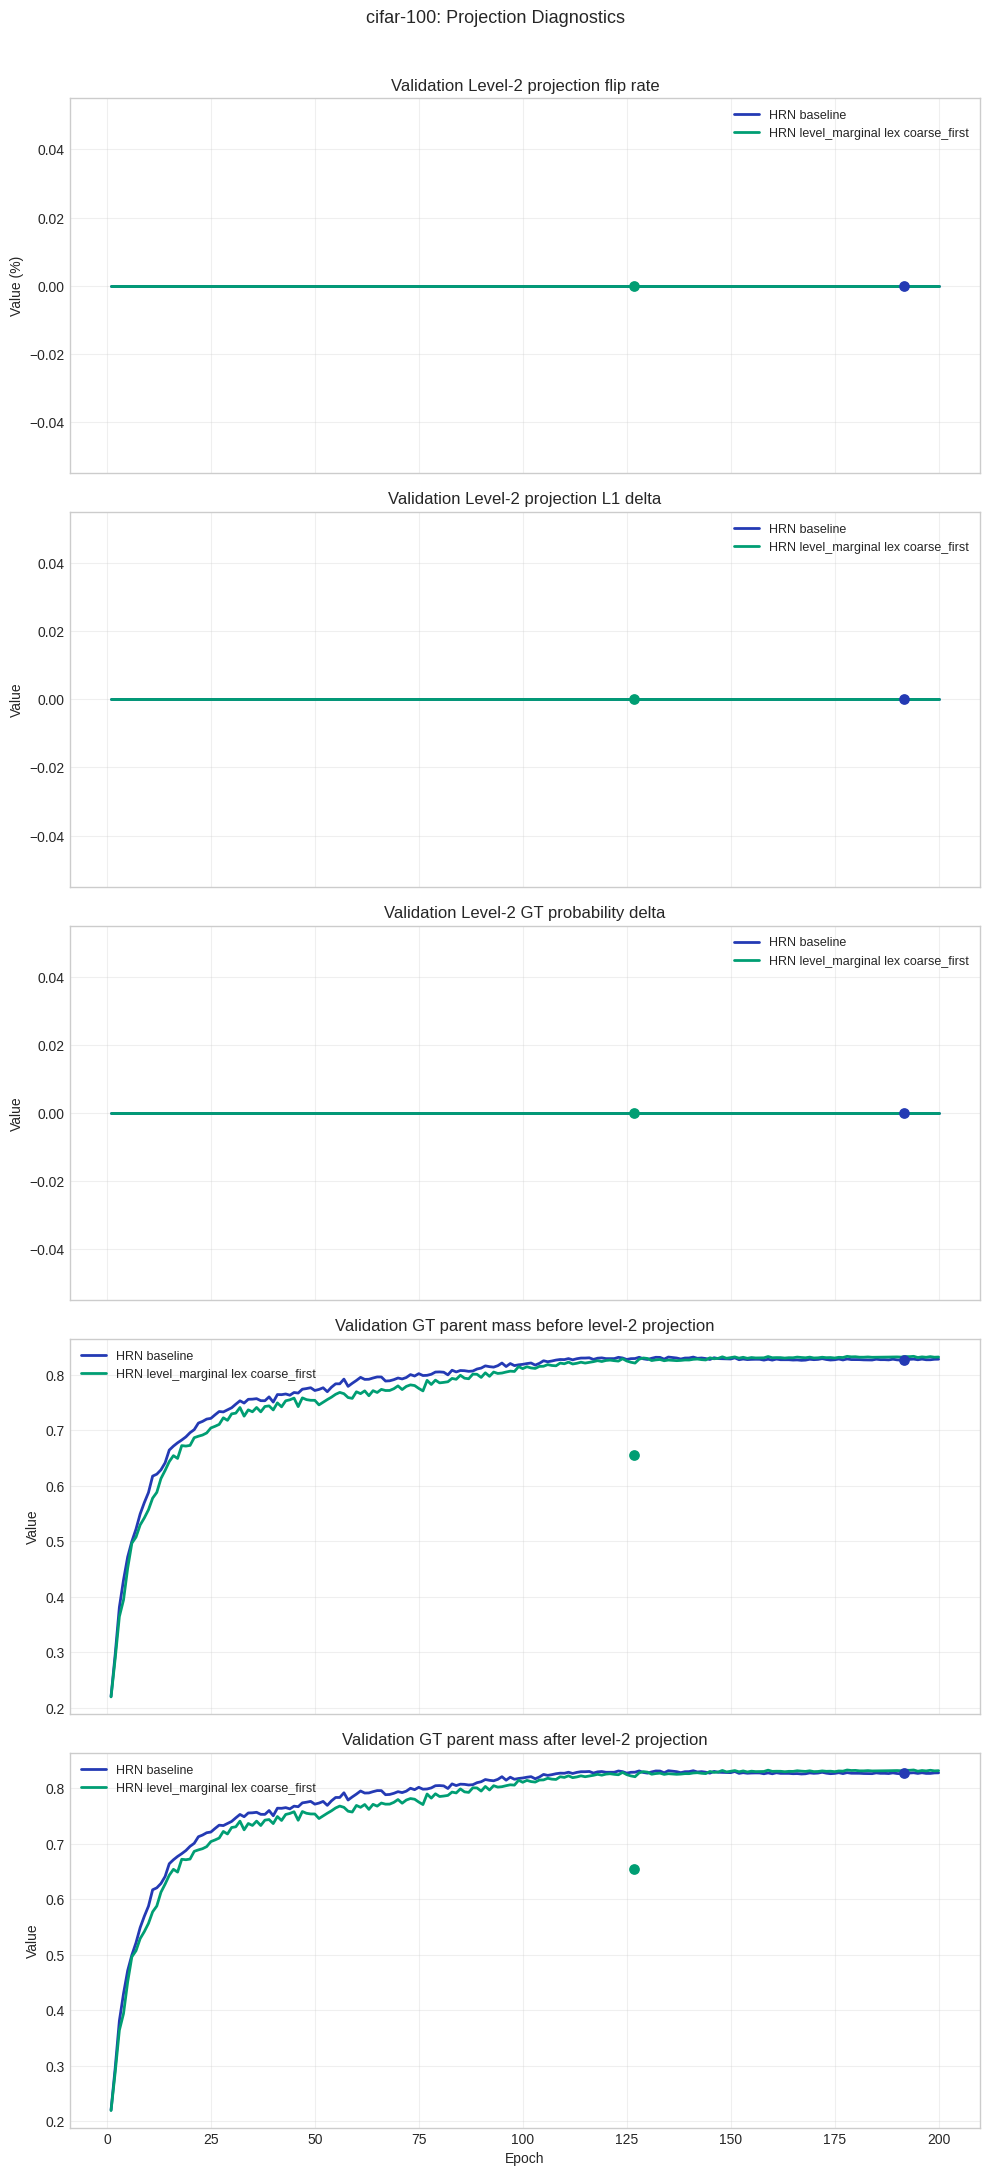

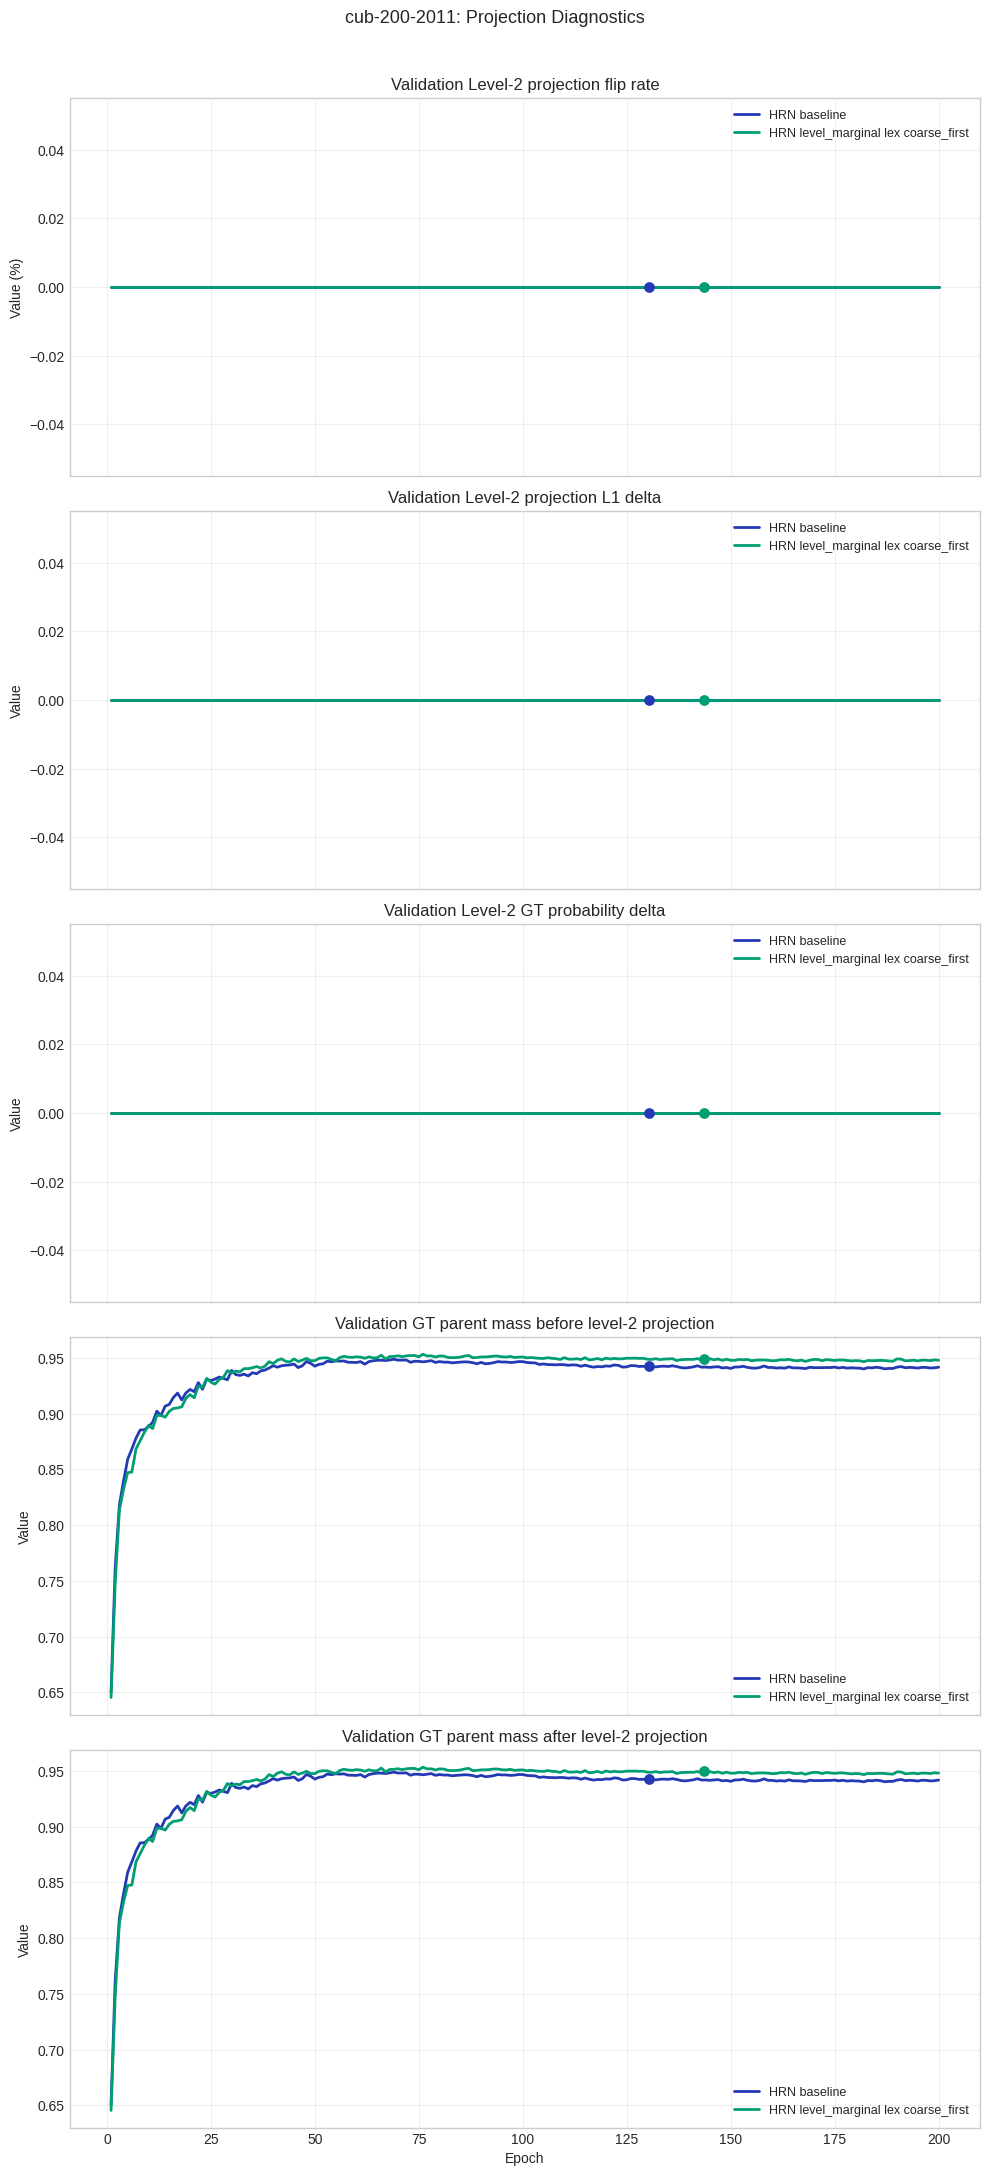

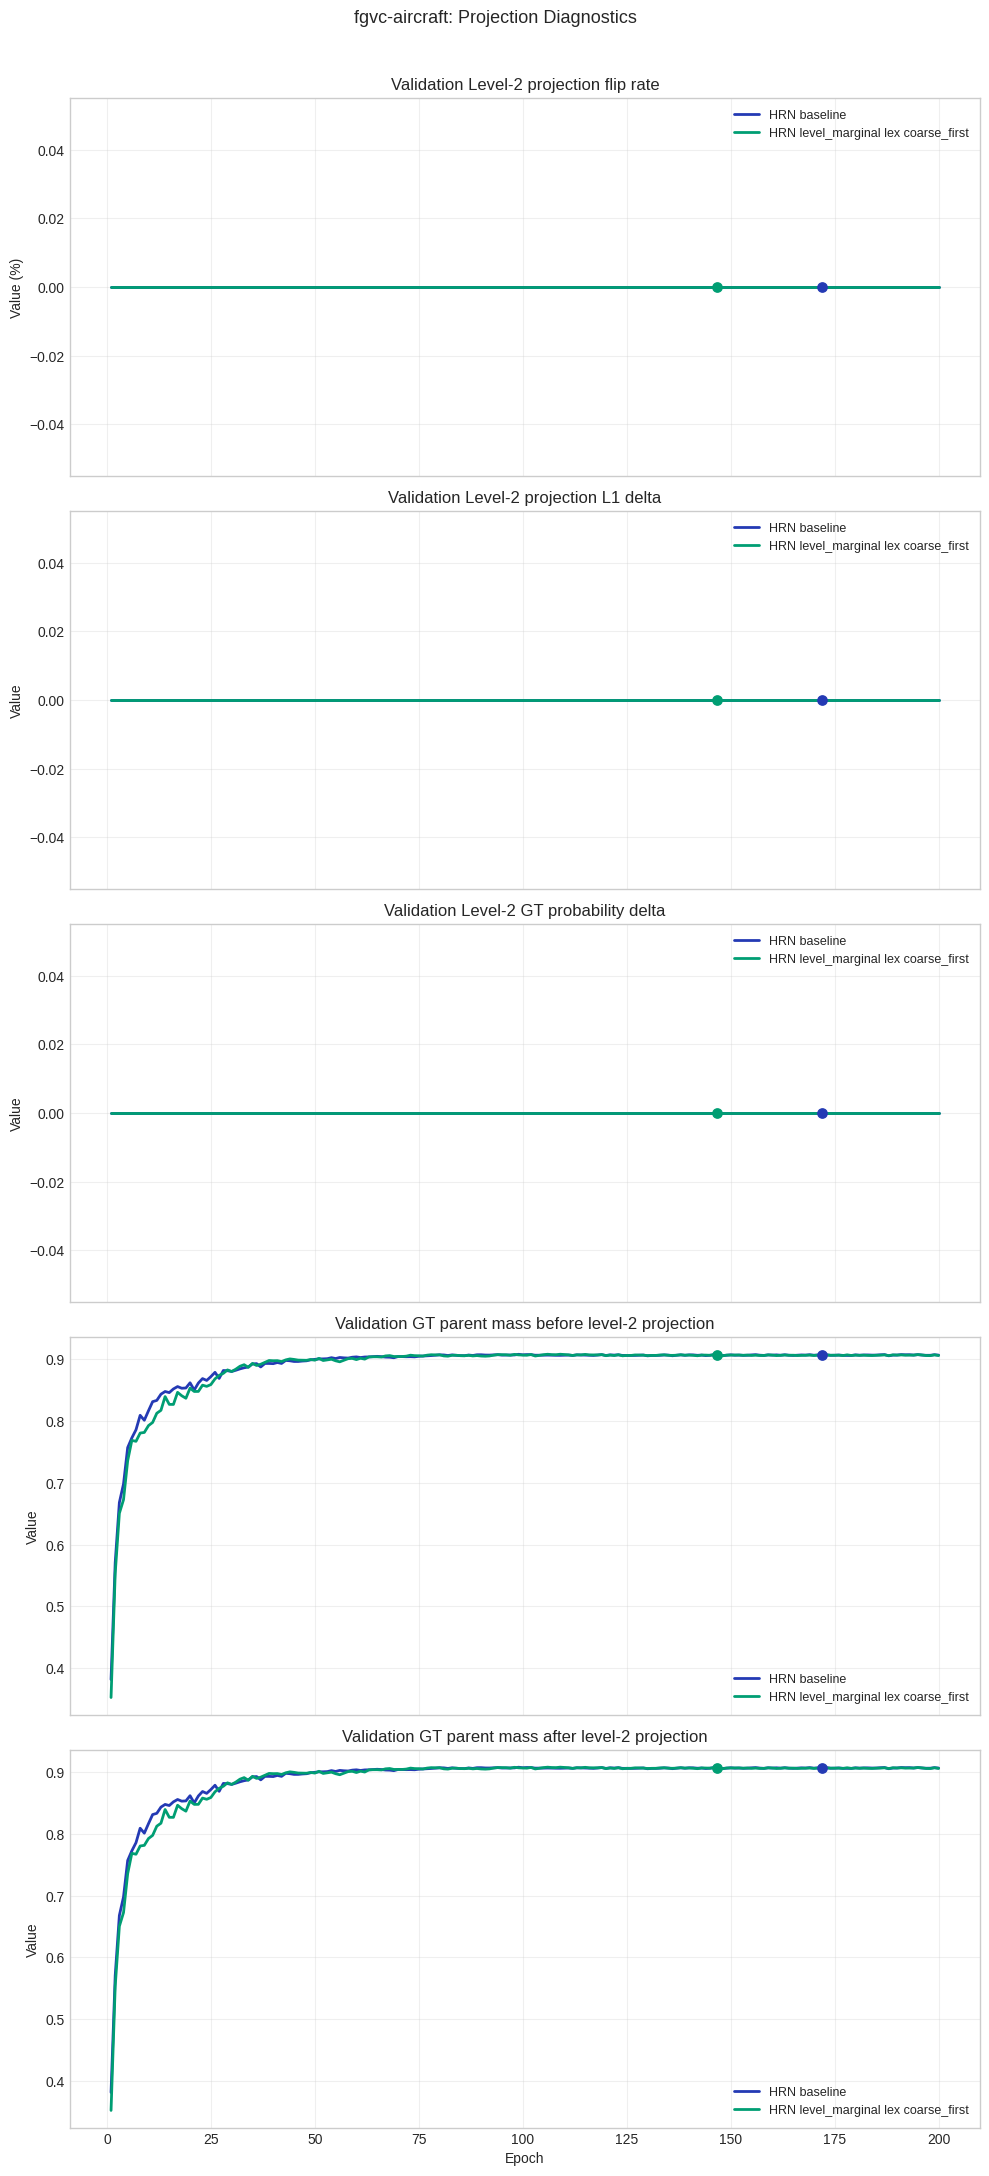

In [5]:
analysis.plot_projection_diagnostics(
    base_diag_specs=[
        ('proj_flip_rate_level_2', 'Level-2 projection flip rate', True, 'val'),
        ('proj_delta_l1_level_2', 'Level-2 projection L1 delta', False, 'val'),
        ('proj_gt_prob_delta_level_2', 'Level-2 GT probability delta', False, 'val'),
        ('gt_parent_mass_pre_l2', 'GT parent mass before level-2 projection', False, 'val'),
        ('gt_parent_mass_post_l2', 'GT parent mass after level-2 projection', False, 'val'),
    ]
)


## Training Loss Comparison

The HRN losses are `tree_loss`, `hier_loss`, `ce_loss_leaf`, and `fine_ce`.


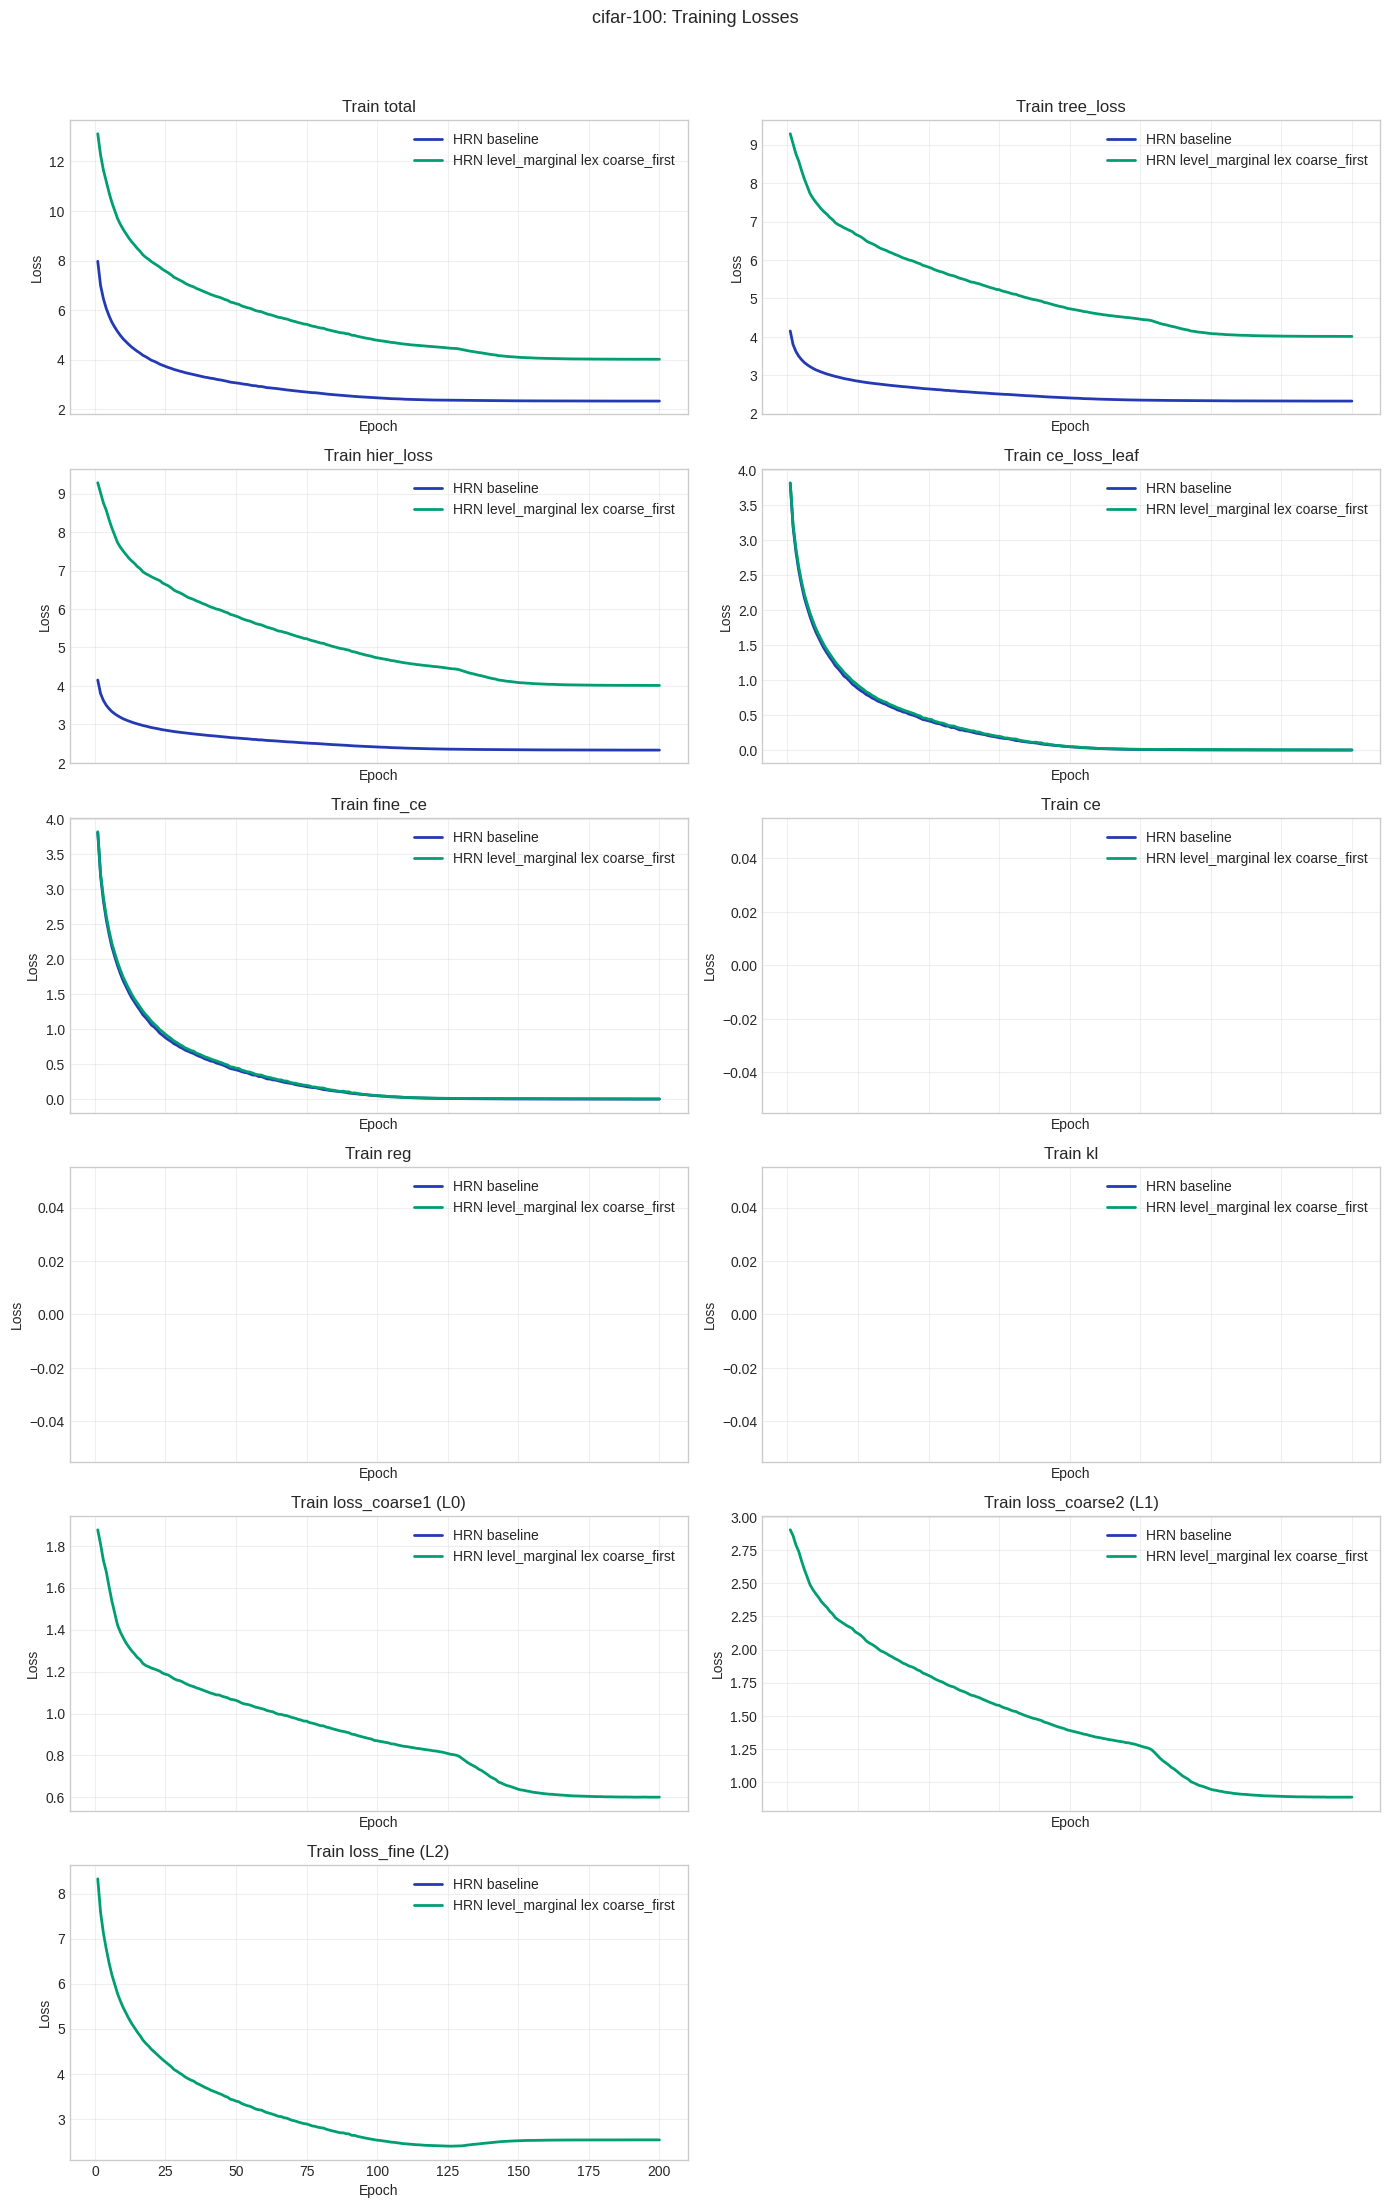

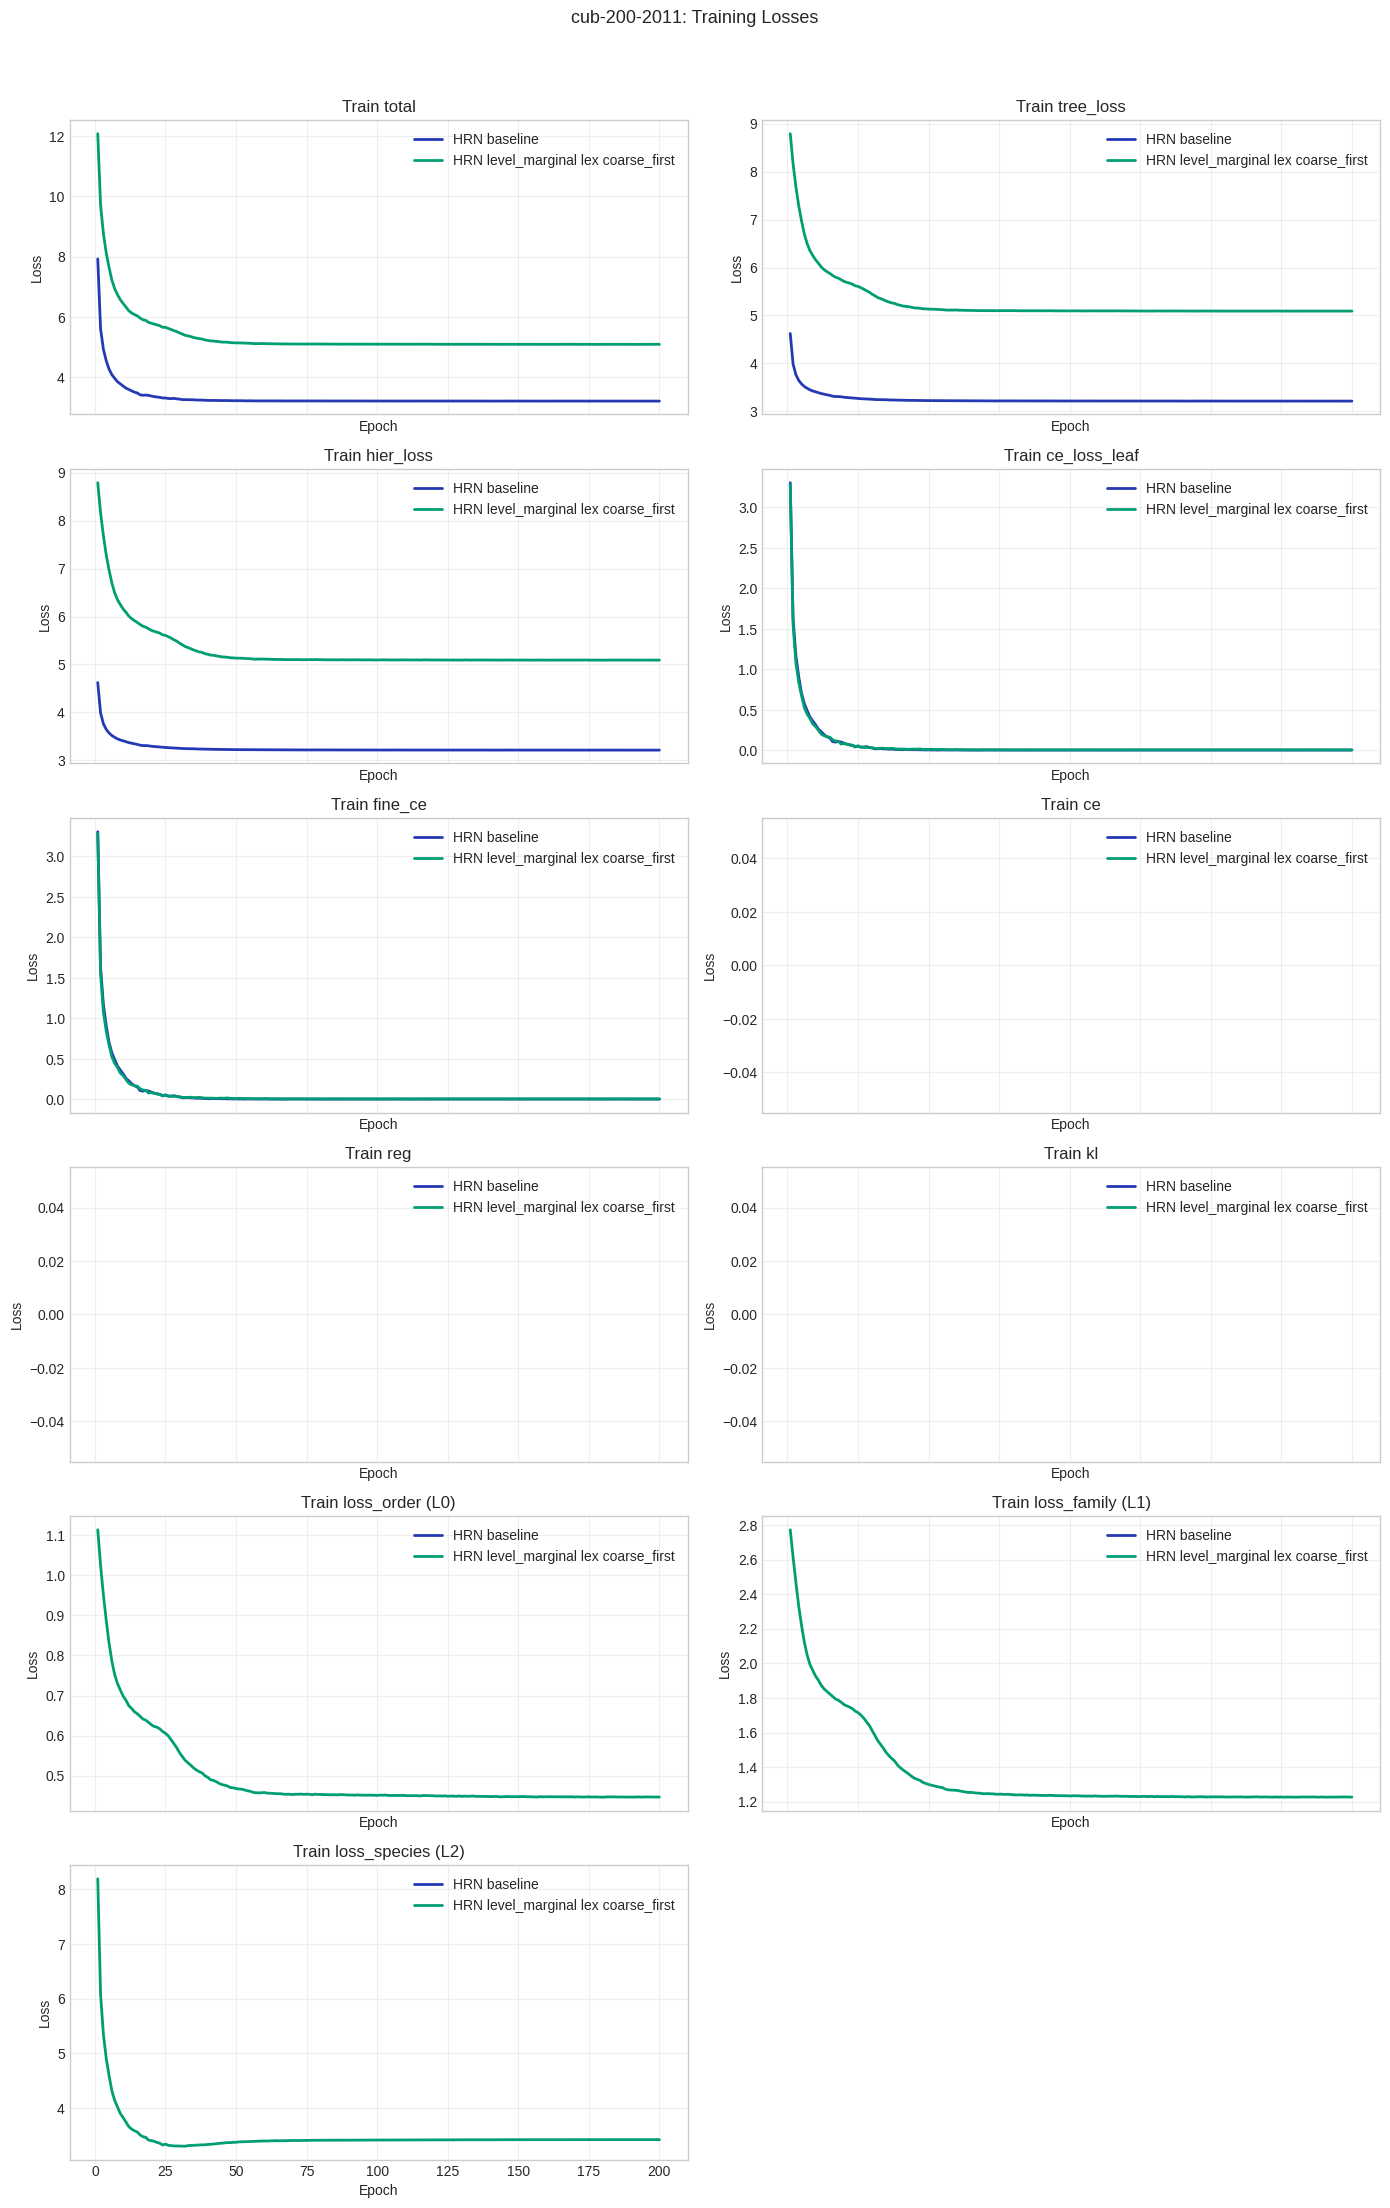

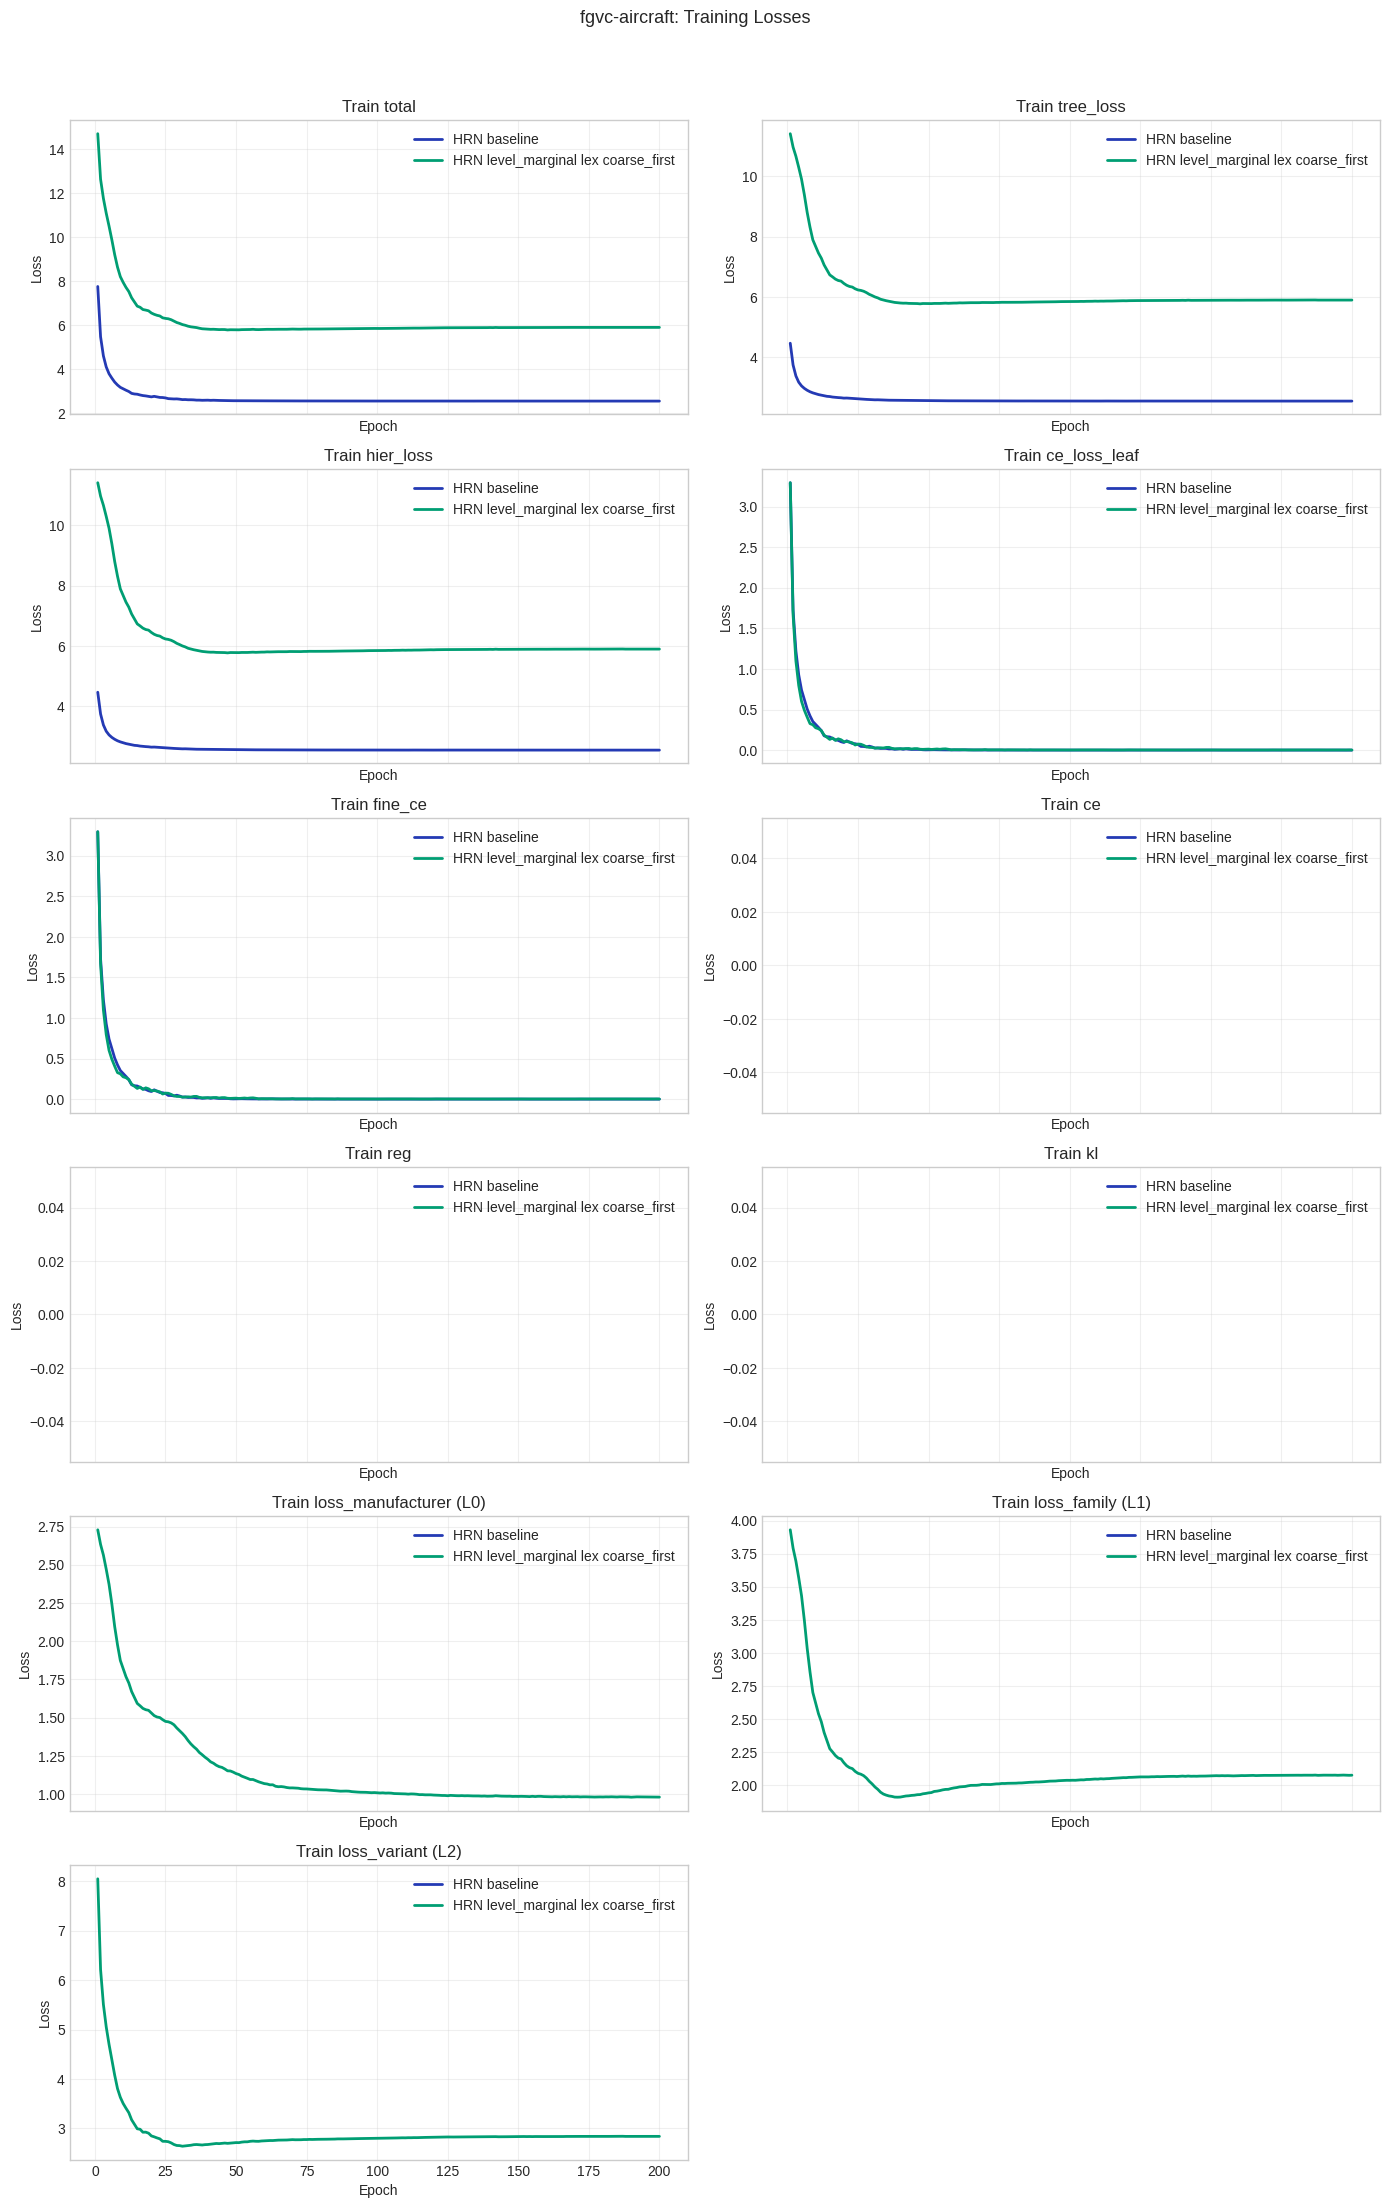

In [6]:
analysis.plot_training_losses(
    aggregate_loss_keys=['total', 'tree_loss', 'hier_loss', 'ce_loss_leaf', 'fine_ce', 'ce', 'reg', 'kl']
)


## Per-Run Per-Level Training Losses

This section shows the differentiable per-level terms emitted by compatible HRN training modes.


[cifar-100] No per-level train losses for HRN baseline


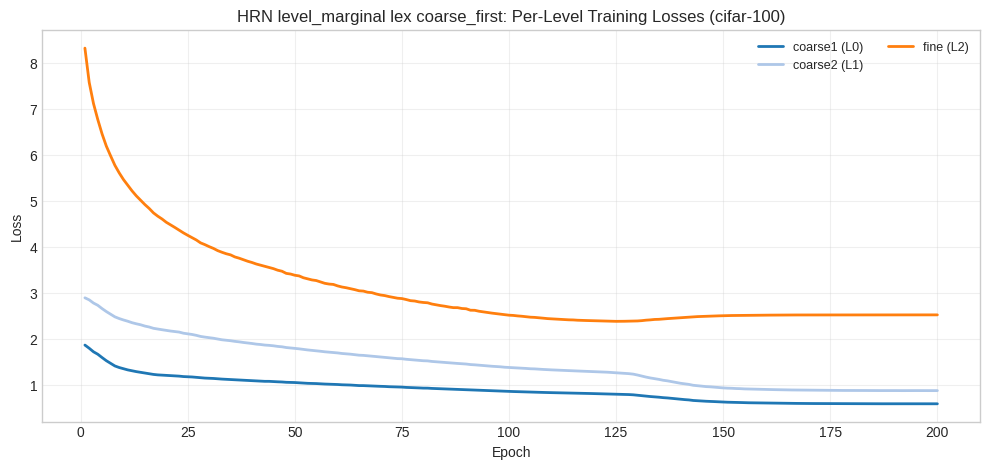

[cub-200-2011] No per-level train losses for HRN baseline


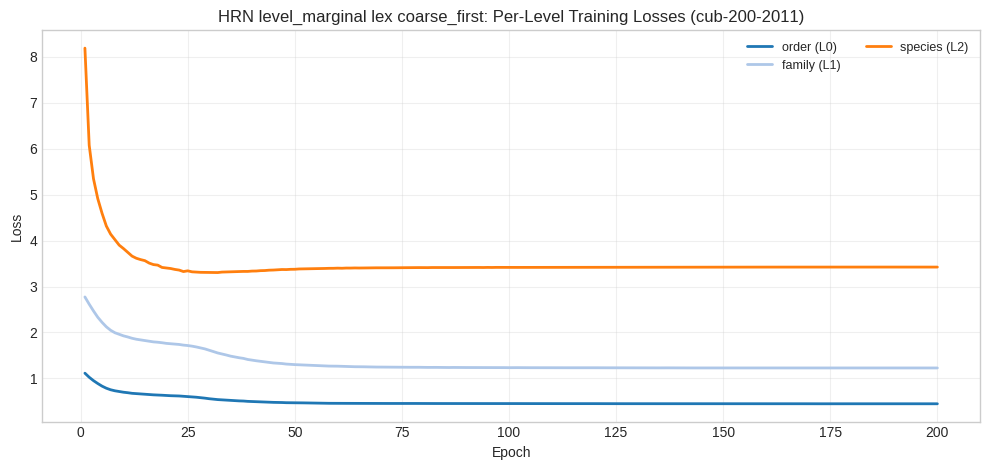

[fgvc-aircraft] No per-level train losses for HRN baseline


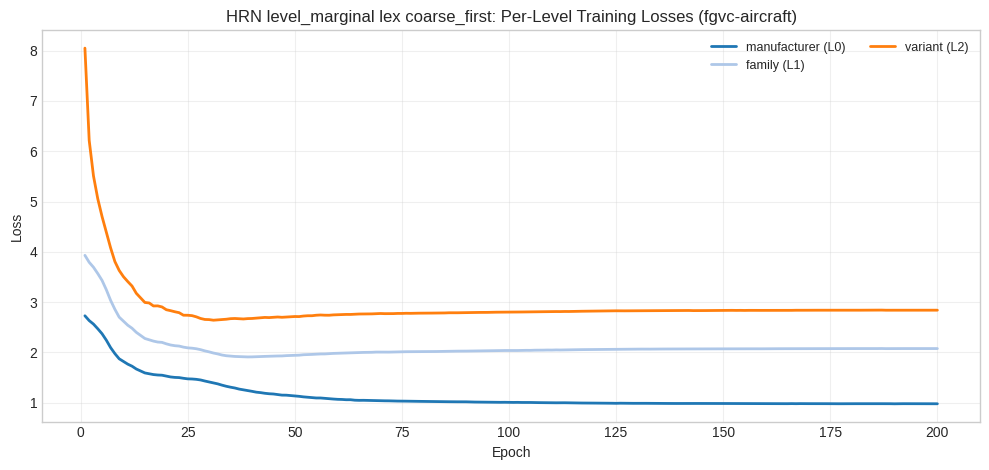

In [7]:
analysis.plot_per_run_per_level_training_losses()


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and lexicographic projection diagnostics stored in `train_metrics` for each epoch.

For the HRN non-lex runs used here, the main expected quantities are raw gradient norms/cosines and parameter movement diagnostics. No `post_*` lexicographic projection diagnostics are expected unless lexicographic training was enabled in a run.

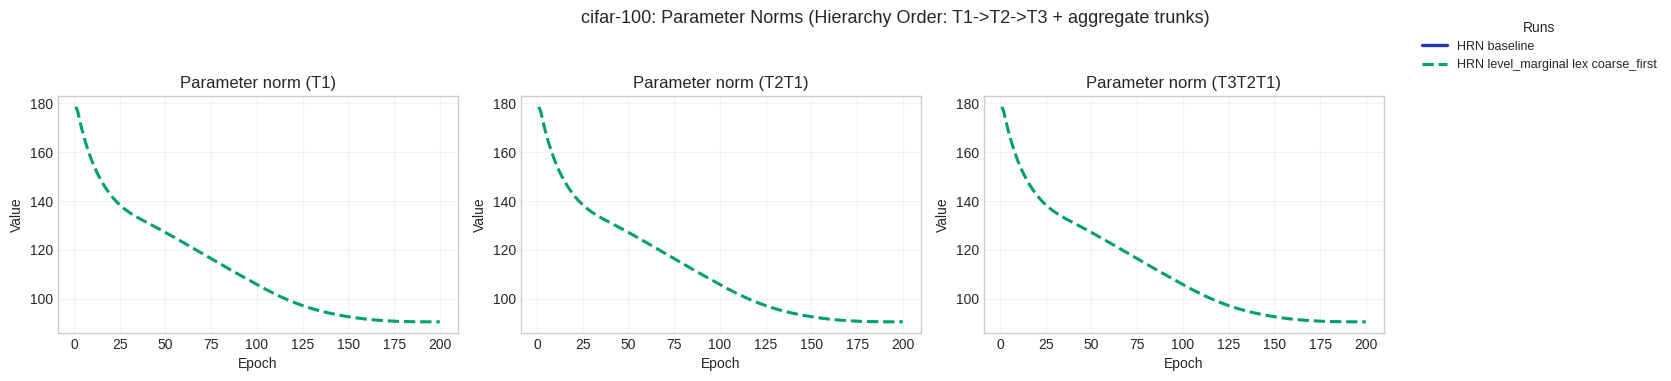

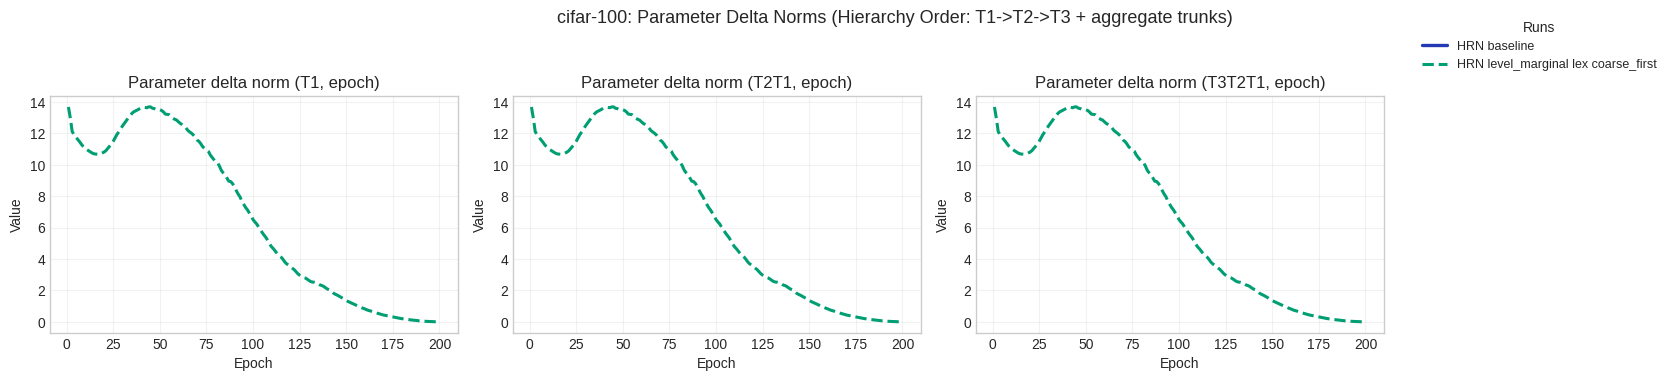

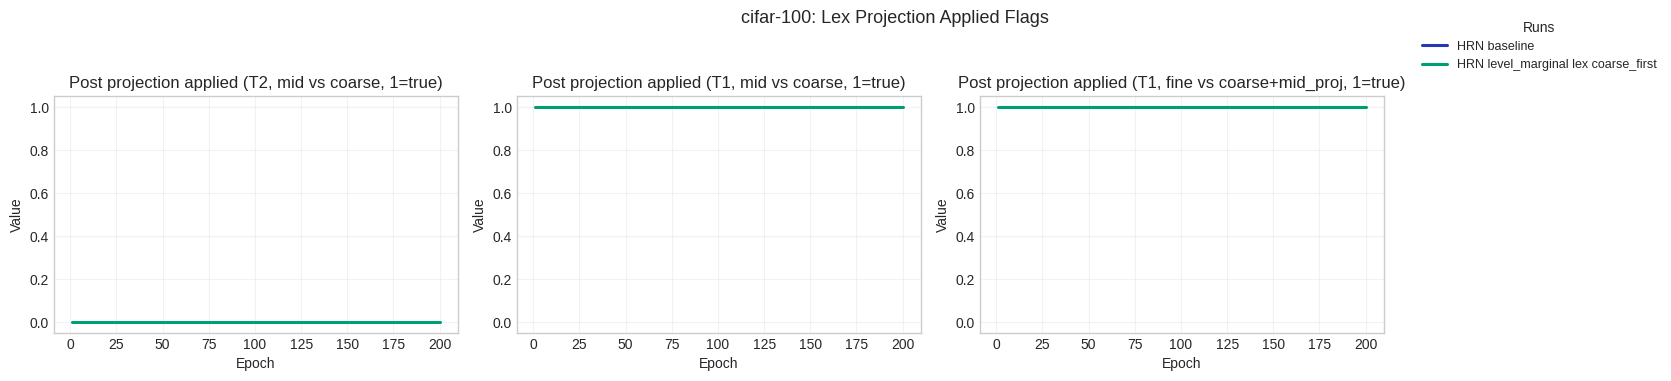

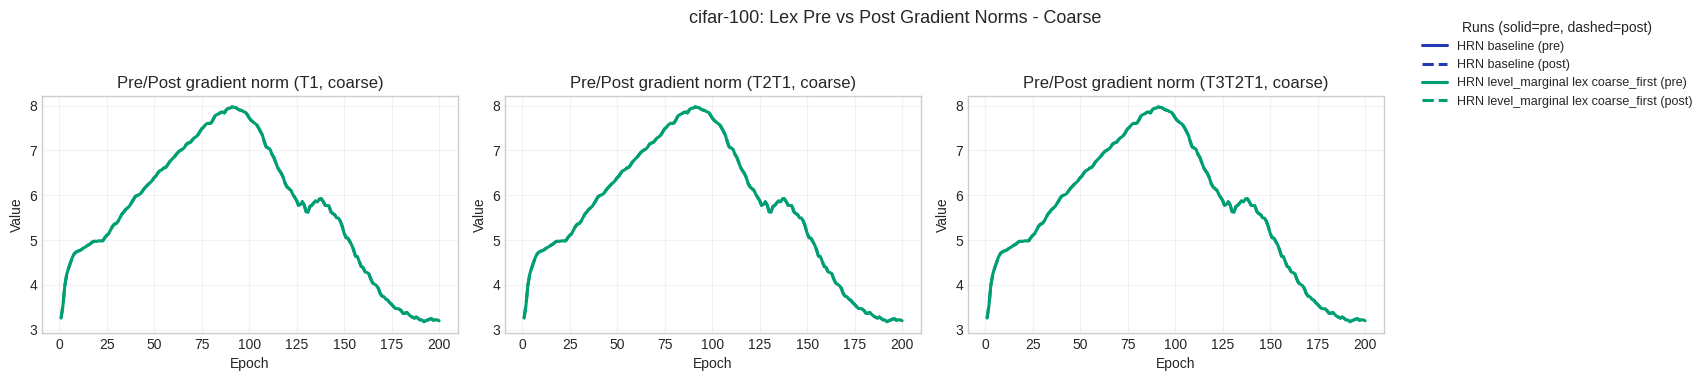

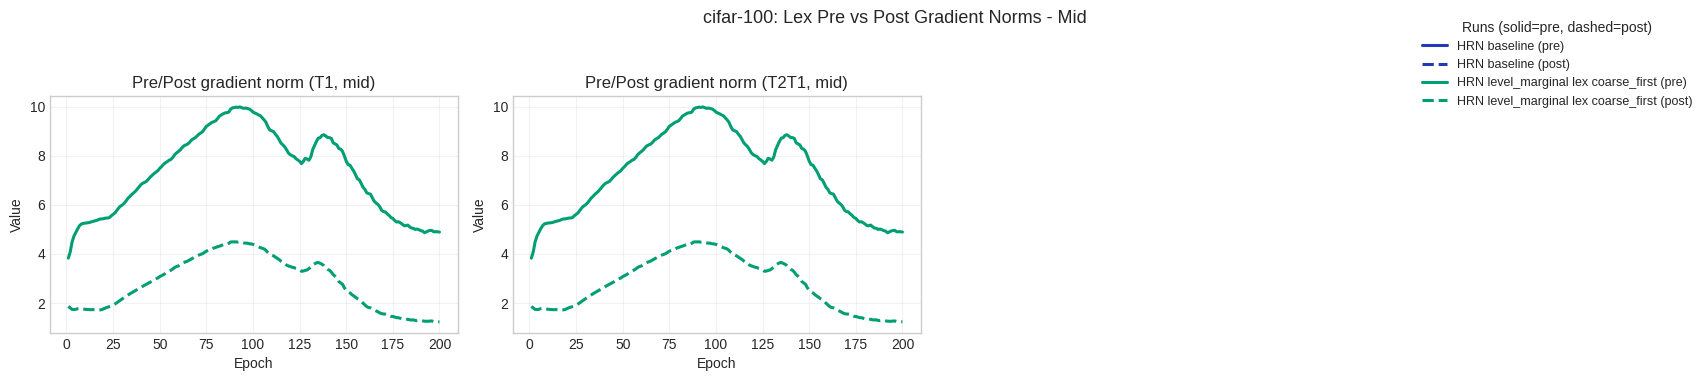

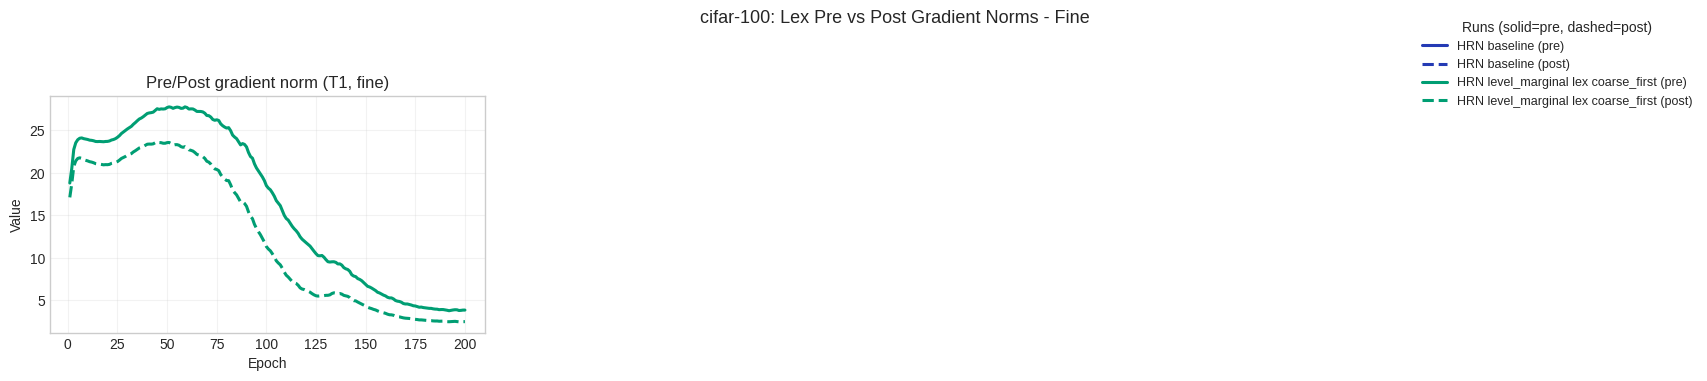

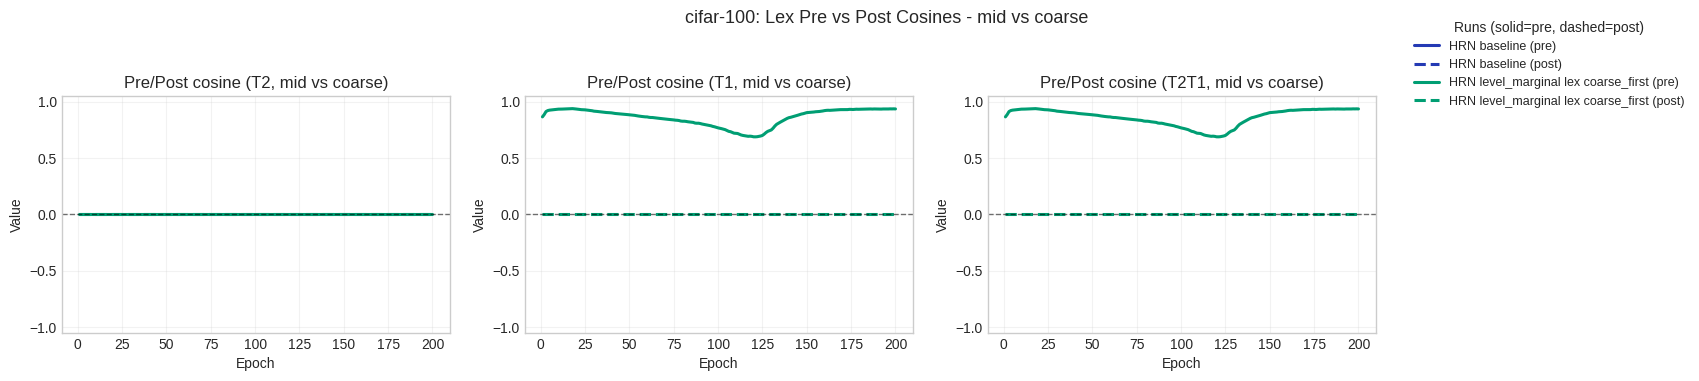

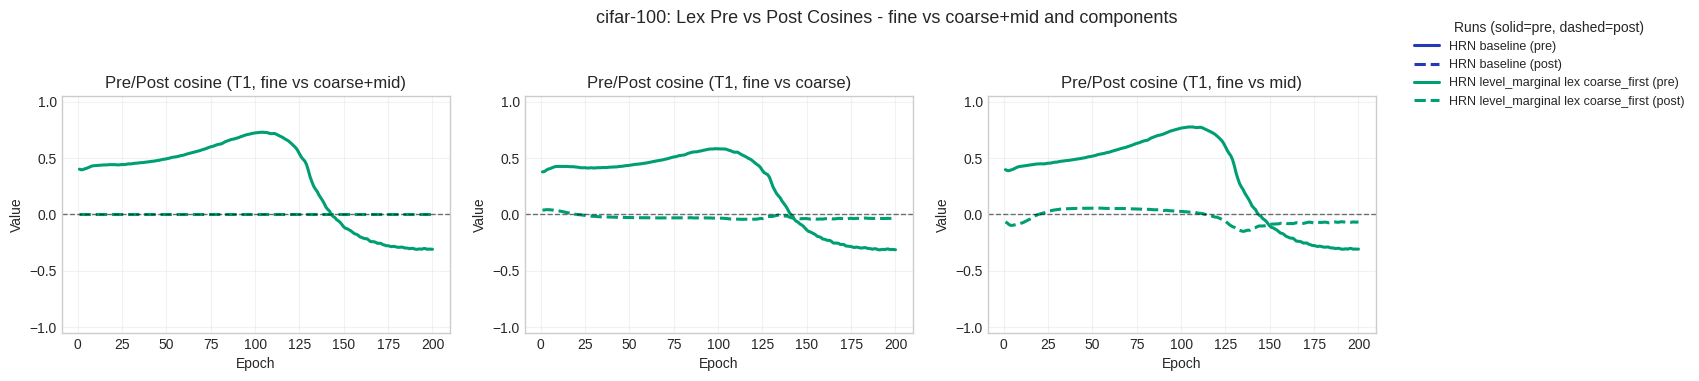

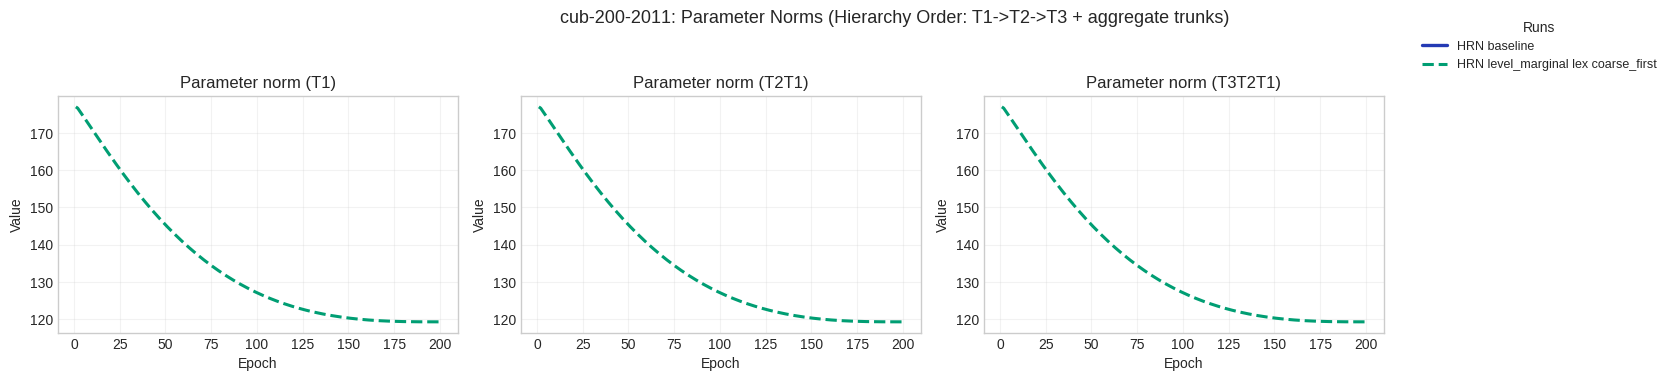

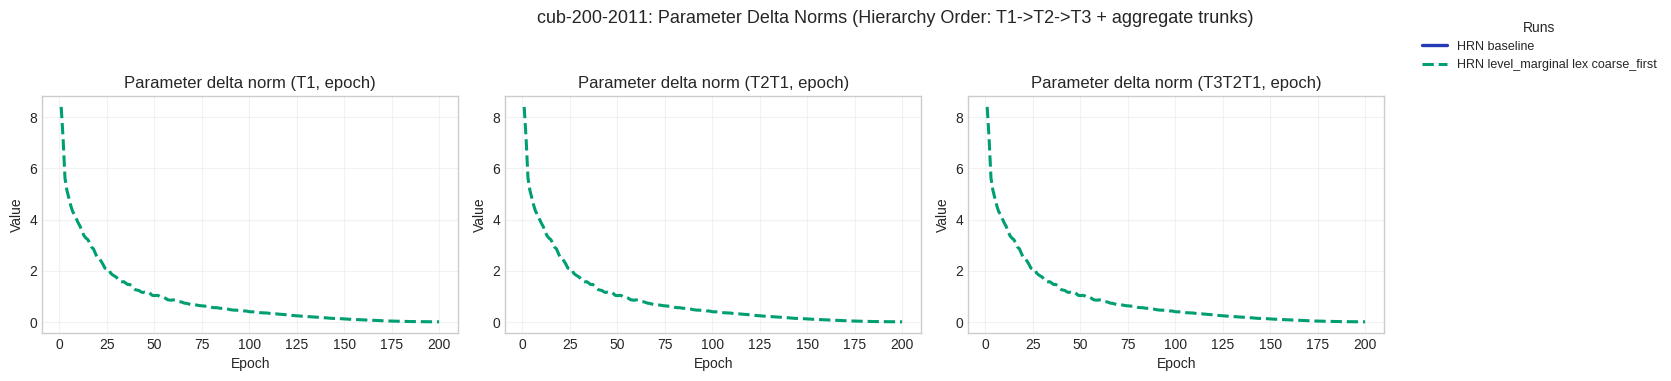

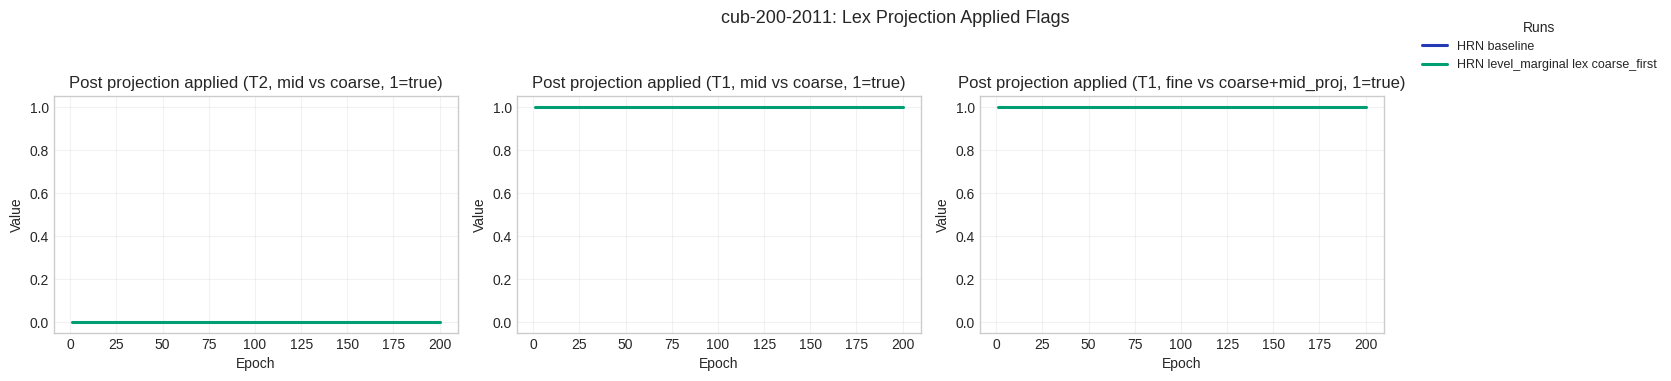

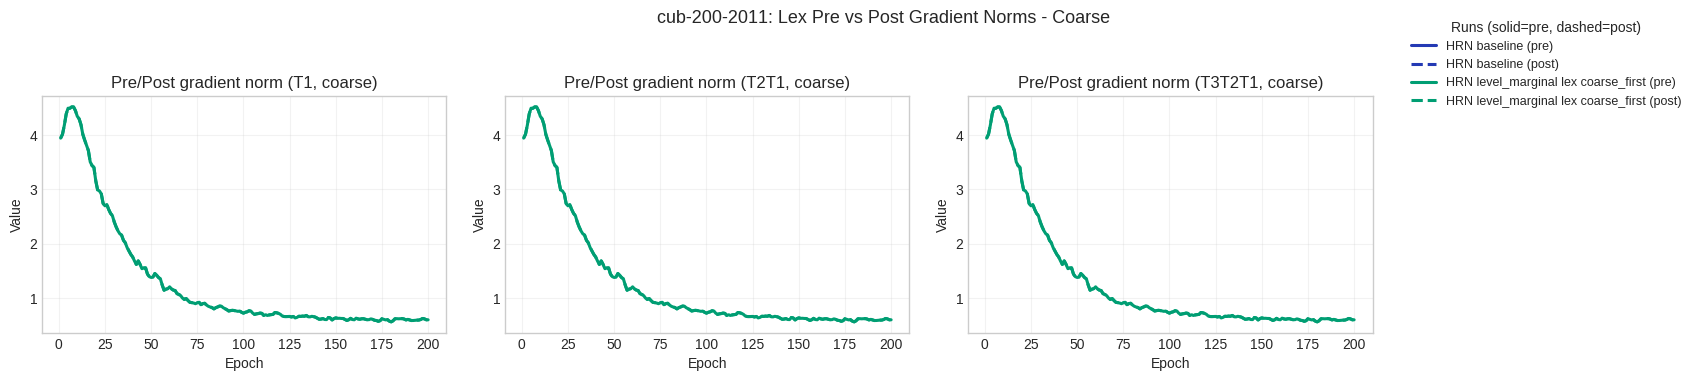

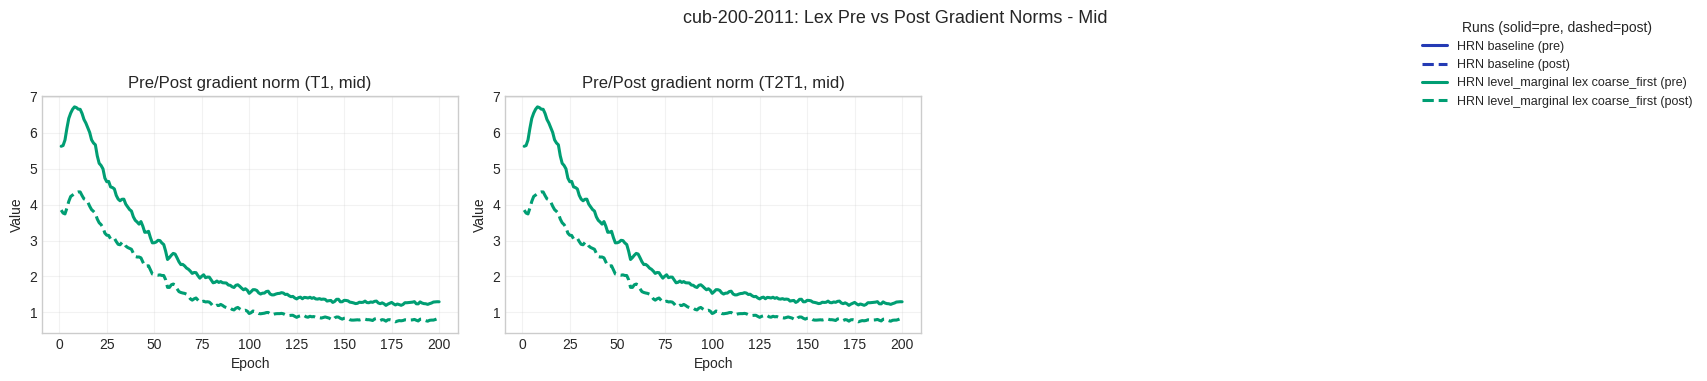

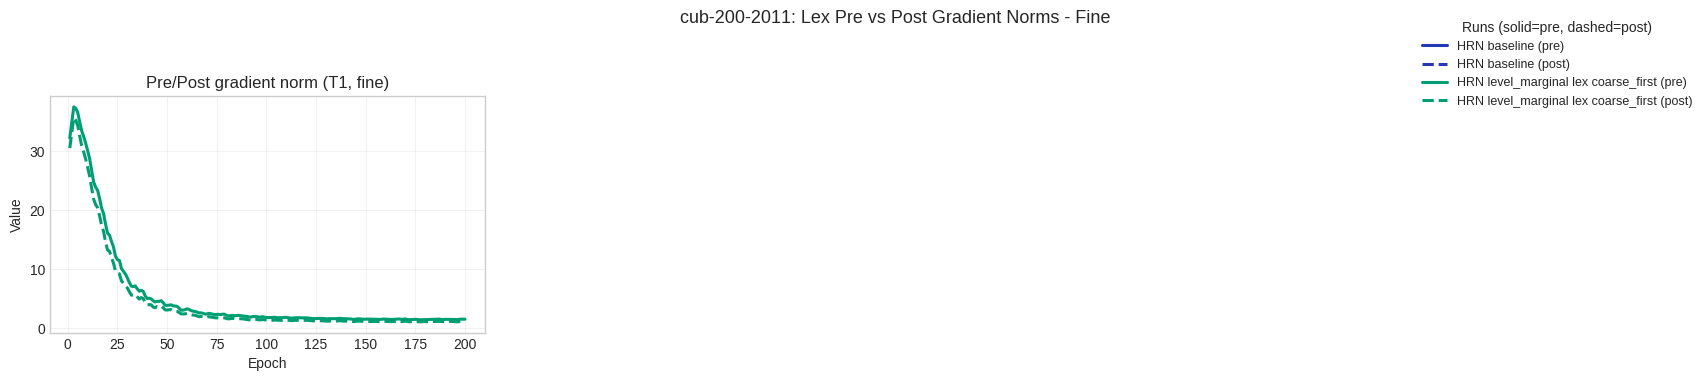

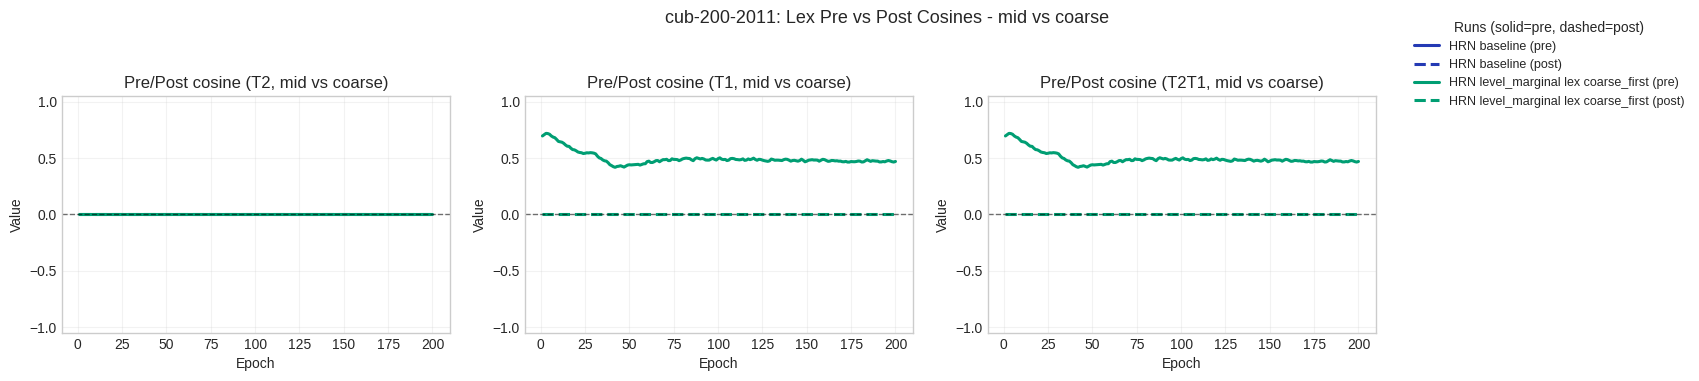

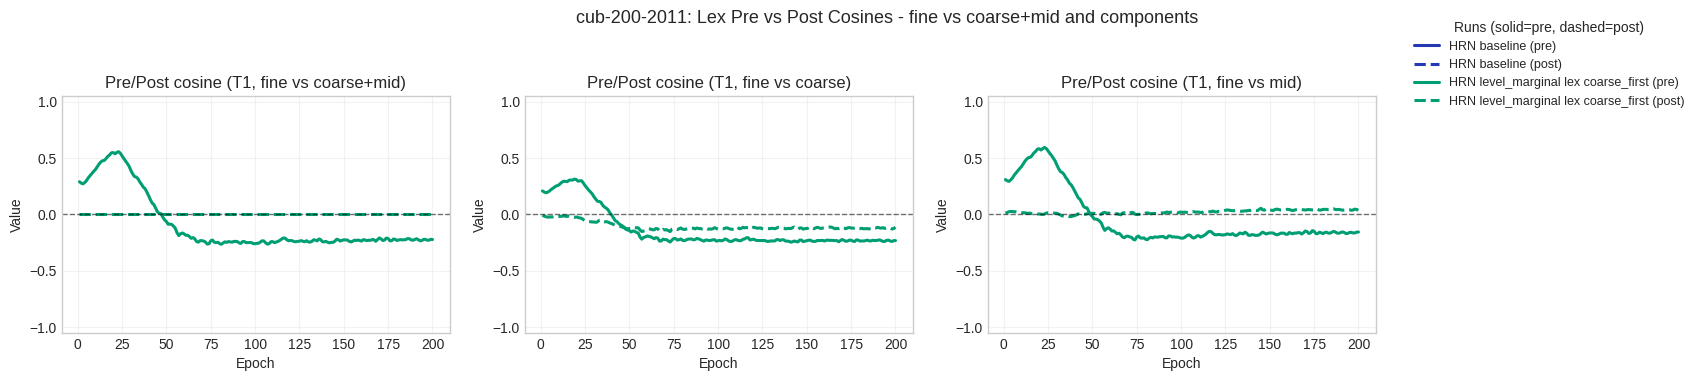

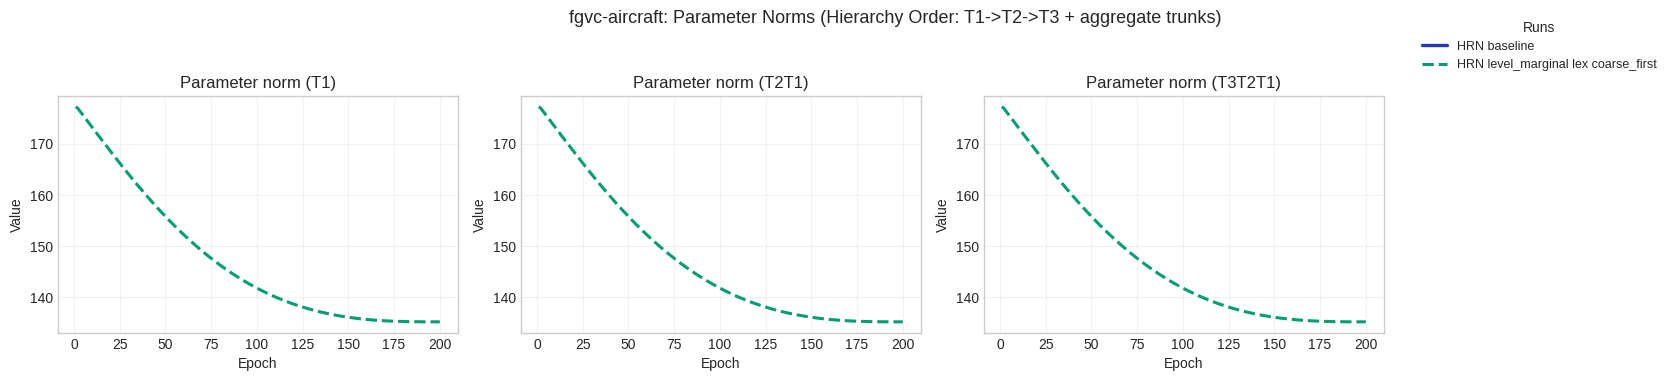

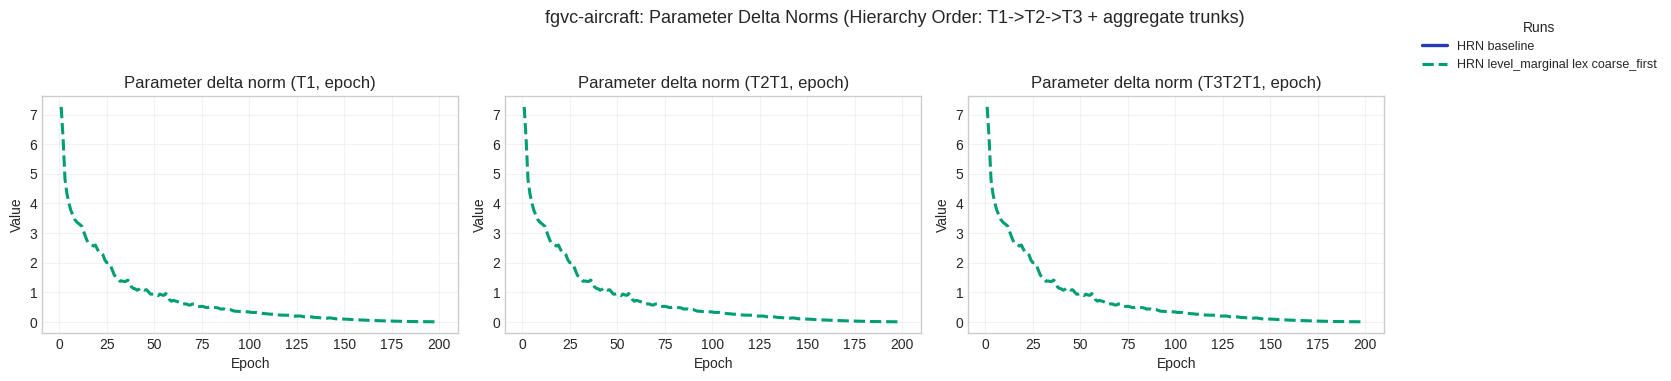

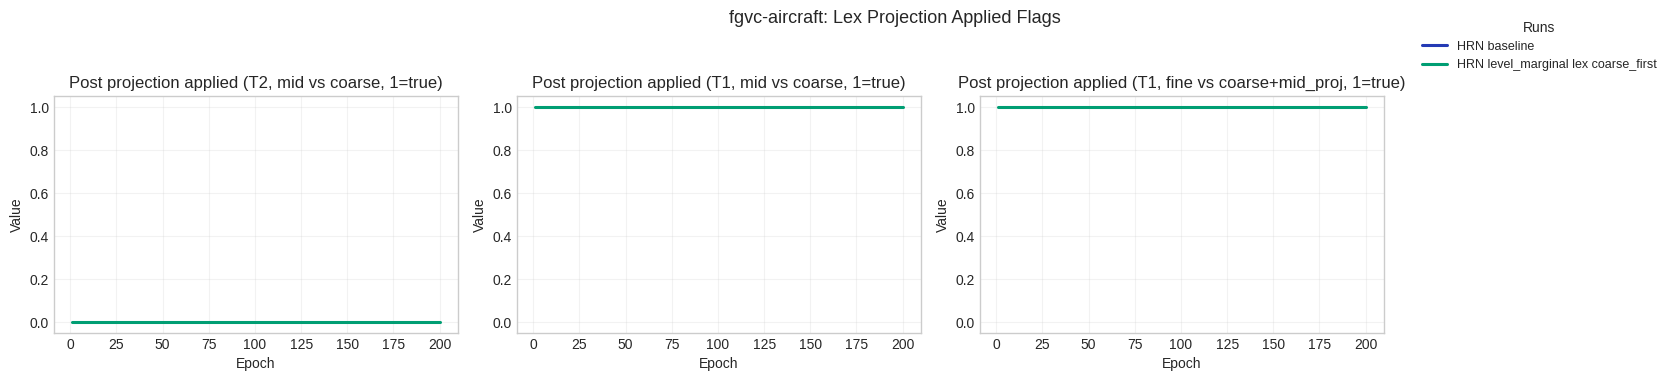

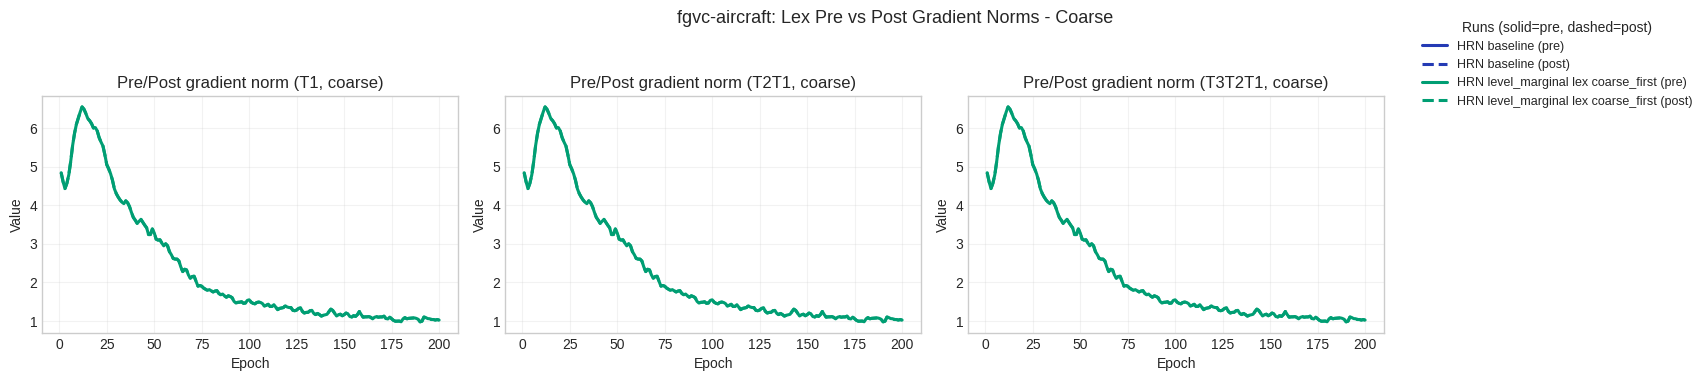

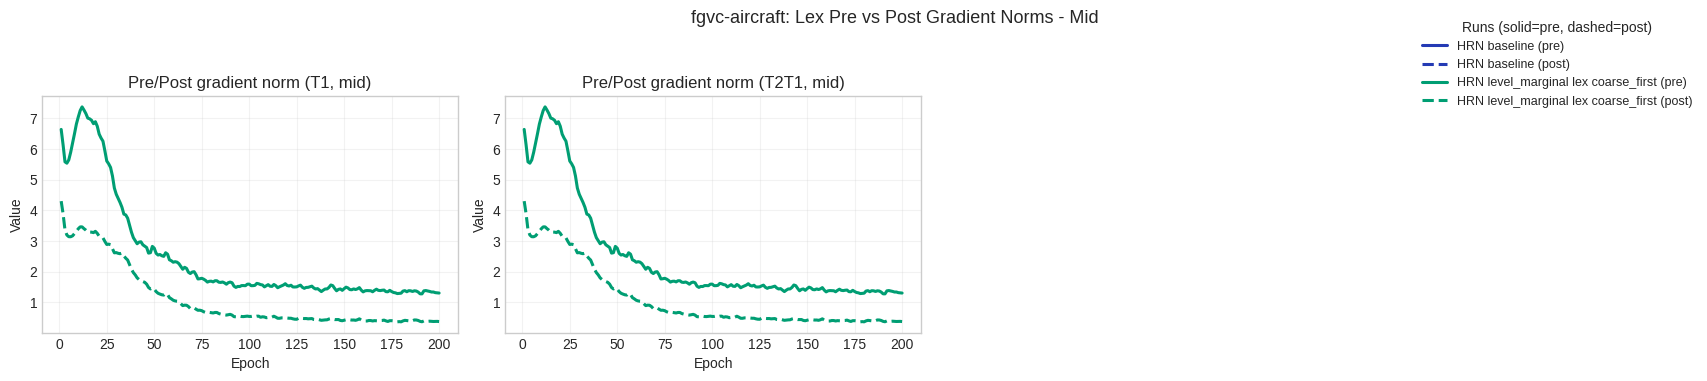

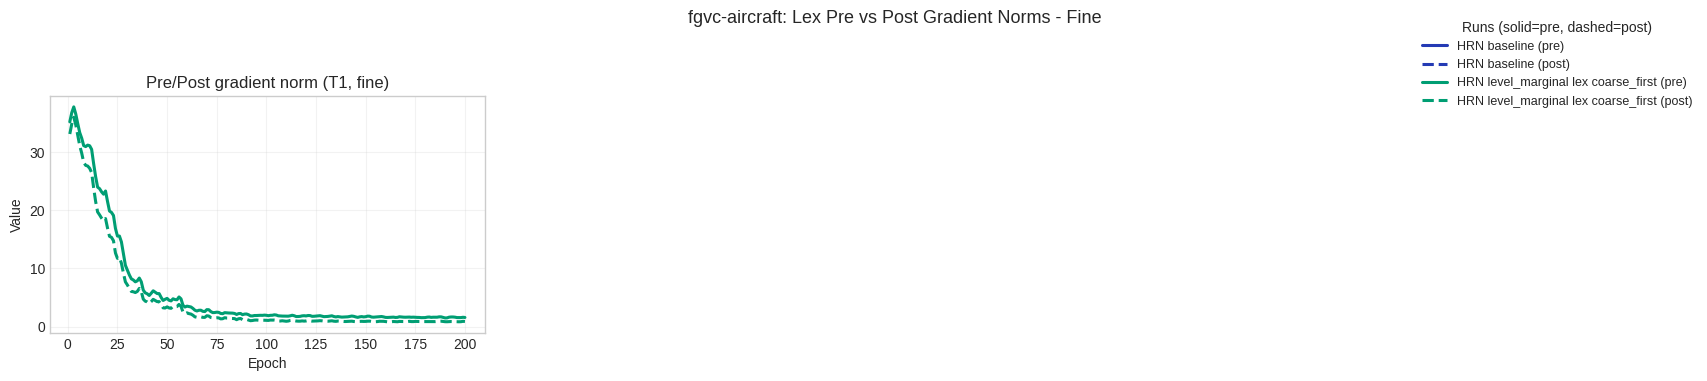

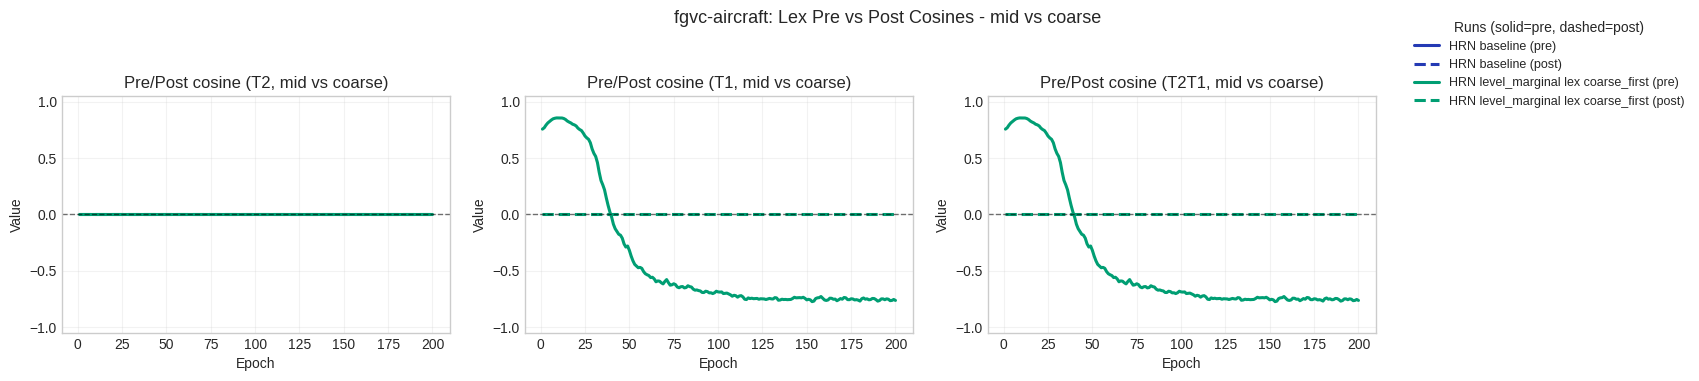

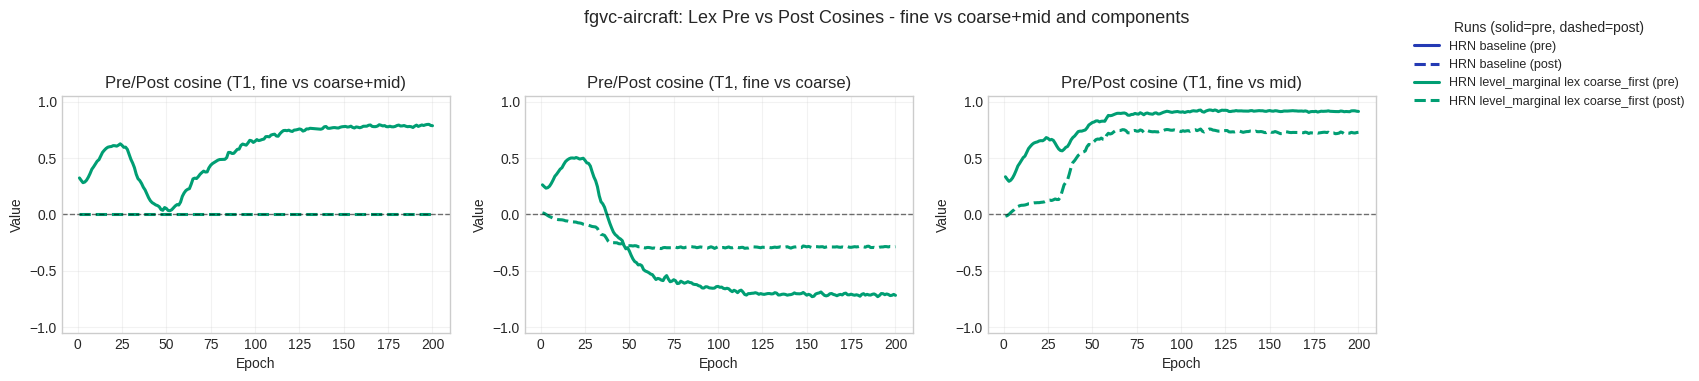

In [8]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)

Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- Cosines near +1 indicate aligned objectives; cosines near -1 indicate conflict; cosines near 0 indicate near-orthogonal level gradients.
- For non-lex runs, compare raw diagnostics only; post-projection metrics are not part of the training update.

## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:

- solid line = top-down decoding
- dashed line = independent decoding
- color = run

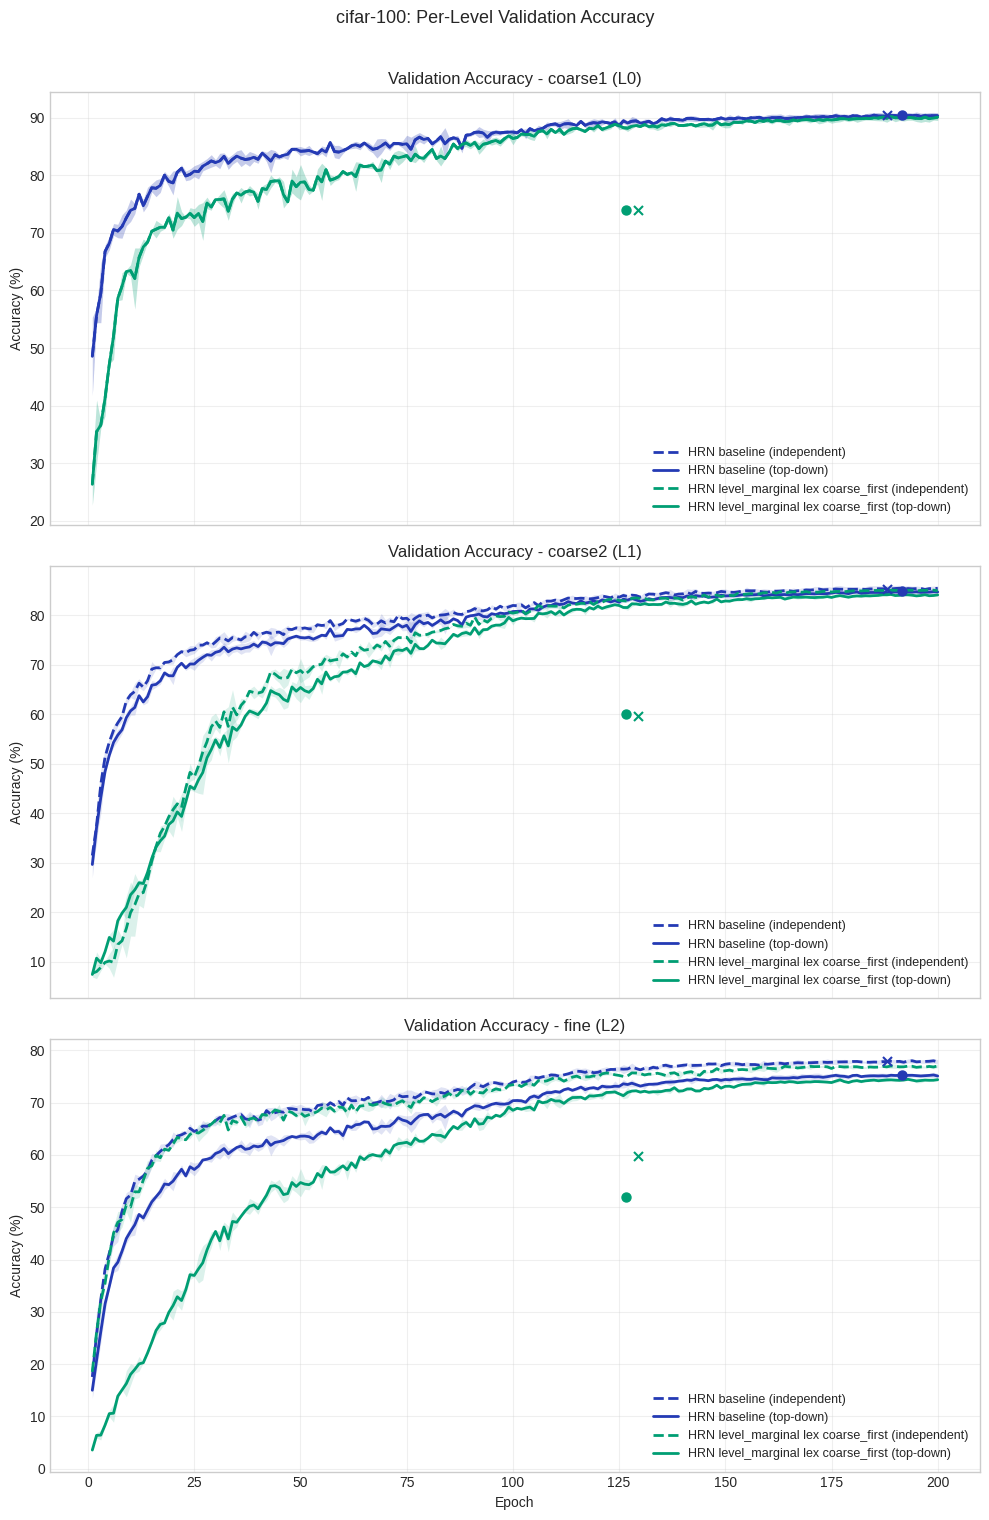

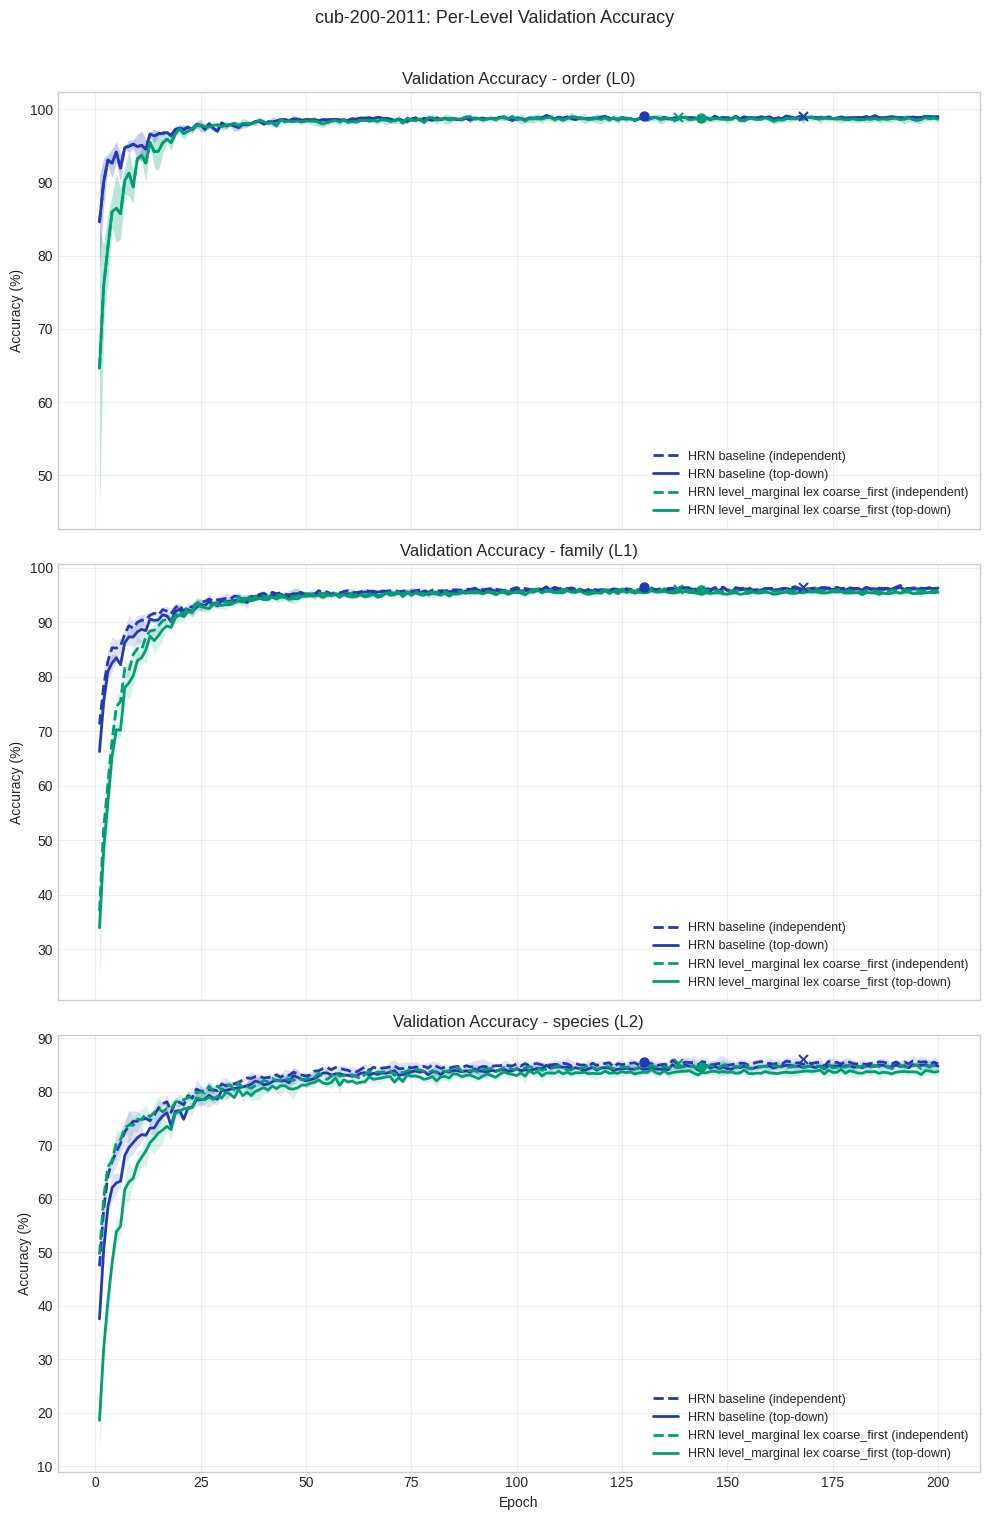

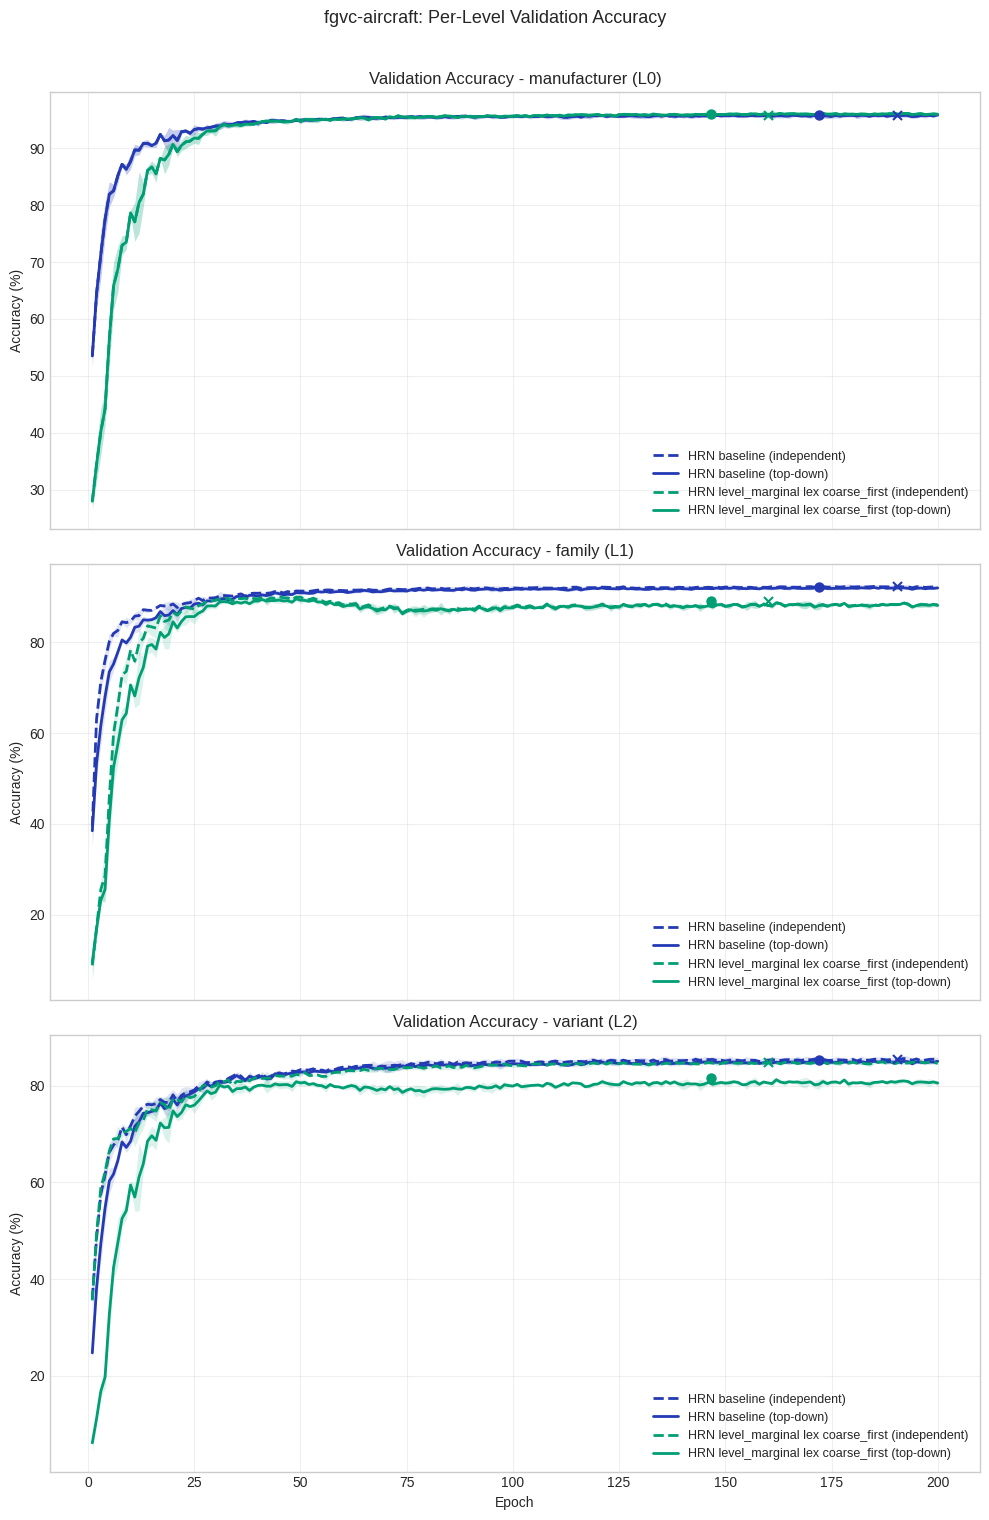

In [9]:
analysis.plot_per_level_validation_accuracy()


## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected HRN runs and reports deltas versus the first run listed for that dataset.

In [10]:
analysis.show_final_test_tables()


### Dataset: `cifar-100`
Baseline run: **HRN baseline**

| Metric | HRN baseline (n=3) | HRN level_marginal lex coarse_first (n=3) |
|---|---:|---:|
| Best epoch (TD/Ind) | 191.7 ± 9.5/188.0 ± 9.8 | 189.0 ± 5.7/193.0 ± 0.0 |
| FPA independent ↑ | **71.67% ± 0.39%** | <u>71.11% ± 0.34% (-0.56 pp)</u> |
| FPA top-down ↑ | **74.17% ± 0.14%** | <u>73.43% ± 0.25% (-0.74 pp)</u> |
| wAP independent ↑ | **78.75% ± 0.11%** | <u>77.98% ± 0.13% (-0.77 pp)</u> |
| wAP top-down ↑ | **76.58% ± 0.12%** | <u>75.90% ± 0.20% (-0.69 pp)</u> |
| TICE independent ↓ | <u>12.54% ± 0.37%</u> | **11.94% ± 0.05% (-0.61 pp)** |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | **0.570 ± 0.008** | <u>0.587 ± 0.004 (+0.018)</u> |
| AHD top-down ↓ | **0.528 ± 0.002** | <u>0.545 ± 0.001 (+0.017)</u> |
| Acc independent coarse1 (L0) ↑ | **89.54% ± 0.06%** | <u>89.20% ± 0.25% (-0.34 pp)</u> |
| Acc top-down coarse1 (L0) ↑ | **89.55% ± 0.06%** | <u>89.16% ± 0.20% (-0.39 pp)</u> |
| Acc independent coarse2 (L1) ↑ | **84.10% ± 0.28%** | <u>83.34% ± 0.37% (-0.75 pp)</u> |
| Acc top-down coarse2 (L1) ↑ | **83.48% ± 0.11%** | <u>82.92% ± 0.06% (-0.56 pp)</u> |
| Acc independent fine (L2) ↑ | **76.82% ± 0.17%** | <u>76.01% ± 0.11% (-0.81 pp)</u> |
| Acc top-down fine (L2) ↑ | **74.17% ± 0.14%** | <u>73.43% ± 0.25% (-0.74 pp)</u> |

### Dataset: `cub-200-2011`
Baseline run: **HRN baseline**

| Metric | HRN baseline (n=3) | HRN level_marginal lex coarse_first (n=3) |
|---|---:|---:|
| Best epoch (TD/Ind) | 130.3 ± 20.3/168.0 ± 25.5 | 143.7 ± 36.6/138.3 ± 29.6 |
| FPA independent ↑ | **84.15% ± 0.37%** | <u>83.45% ± 0.46% (-0.70 pp)</u> |
| FPA top-down ↑ | **85.03% ± 0.17%** | <u>84.04% ± 0.19% (-1.00 pp)</u> |
| wAP independent ↑ | **87.90% ± 0.20%** | <u>87.51% ± 0.22% (-0.39 pp)</u> |
| wAP top-down ↑ | **87.29% ± 0.13%** | <u>86.39% ± 0.18% (-0.90 pp)</u> |
| TICE independent ↓ | **4.05% ± 0.09%** | <u>4.07% ± 0.17% (+0.02 pp)</u> |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | **0.222 ± 0.004** | <u>0.234 ± 0.008 (+0.012)</u> |
| AHD top-down ↓ | **0.209 ± 0.002** | <u>0.228 ± 0.004 (+0.019)</u> |
| Acc independent order (L0) ↑ | **98.76% ± 0.08%** | <u>98.68% ± 0.10% (-0.08 pp)</u> |
| Acc top-down order (L0) ↑ | **98.81% ± 0.03%** | <u>98.57% ± 0.04% (-0.24 pp)</u> |
| Acc independent family (L1) ↑ | **95.29% ± 0.06%** | <u>94.79% ± 0.23% (-0.50 pp)</u> |
| Acc top-down family (L1) ↑ | **95.24% ± 0.07%** | <u>94.60% ± 0.21% (-0.64 pp)</u> |
| Acc independent species (L2) ↑ | **85.79% ± 0.25%** | <u>85.40% ± 0.24% (-0.39 pp)</u> |
| Acc top-down species (L2) ↑ | **85.03% ± 0.17%** | <u>84.04% ± 0.19% (-1.00 pp)</u> |

### Dataset: `fgvc-aircraft`
Baseline run: **HRN baseline**

| Metric | HRN baseline (n=3) | HRN level_marginal lex coarse_first (n=3) |
|---|---:|---:|
| Best epoch (TD/Ind) | 172.0 ± 25.2/190.3 ± 10.6 | 146.7 ± 22.4/160.0 ± 35.7 |
| FPA independent ↑ | **84.77% ± 0.06%** | <u>80.64% ± 0.32% (-4.13 pp)</u> |
| FPA top-down ↑ | **86.06% ± 0.22%** | <u>81.98% ± 0.24% (-4.08 pp)</u> |
| wAP independent ↑ | **90.20% ± 0.16%** | <u>88.31% ± 0.23% (-1.89 pp)</u> |
| wAP top-down ↑ | **89.83% ± 0.14%** | <u>86.39% ± 0.20% (-3.44 pp)</u> |
| TICE independent ↓ | **5.33% ± 0.45%** | <u>9.08% ± 0.29% (+3.75 pp)</u> |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | **0.273 ± 0.004** | <u>0.351 ± 0.008 (+0.078)</u> |
| AHD top-down ↓ | **0.253 ± 0.004** | <u>0.336 ± 0.006 (+0.083)</u> |
| Acc independent manufacturer (L0) ↑ | **96.09% ± 0.06%** | <u>95.85% ± 0.28% (-0.24 pp)</u> |
| Acc top-down manufacturer (L0) ↑ | **96.06% ± 0.12%** | <u>95.77% ± 0.21% (-0.29 pp)</u> |
| Acc independent family (L1) ↑ | **92.93% ± 0.33%** | <u>88.87% ± 0.40% (-4.06 pp)</u> |
| Acc top-down family (L1) ↑ | **92.55% ± 0.18%** | <u>88.67% ± 0.18% (-3.88 pp)</u> |
| Acc independent variant (L2) ↑ | **86.53% ± 0.08%** | <u>85.66% ± 0.18% (-0.87 pp)</u> |
| Acc top-down variant (L2) ↑ | **86.06% ± 0.22%** | <u>81.98% ± 0.24% (-4.08 pp)</u> |